In [1]:
import pandas as pd
import pypowsybl.network as pn
import pypowsybl as pp
from pypowsybl_jupyter import nad_explorer
import re
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import builtins
import itertools
import importlib
import utils
from pypowsybl_jupyter import nad_explorer

In [2]:
importlib.reload(utils)

<module 'utils' from 'd:\\dev\\powsybl-open-loadflow-knitro-solver\\utils.py'>

In [3]:
from utils import edges_with_impedance, median,cluster_subgraph,network_construction, type_controller, unique_list, plot_slack_cluster, slack_subgraph_2nd, plot_graph, dfs_slack_2nd, slack_subgraph, has_slack, visualize_graph, dfs_with_slack, median 

# Première perturbation 

In [4]:
# slack_info 
network_name = "test_active_power_and_correction/ieee300/ieee300"
network ="ieee300"
pertubation = "active"
data = pd.read_csv(
    network_name + "_" + pertubation + "-perturbation.csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
#data = data.replace(r"\[", "", regex=True).replace(r"\]", "", regex=True)
#namefile_initial = 'ieee118-active-perturbation'
optim_info = pd.read_csv(
    network_name + "_" + pertubation + "-perturbation_optim_info.csv",
    sep=";",
    engine="python",
    index_col=False,
)
extension_in = '.xiidm'
# extension_out = '.svg'
# possibilité de lire un network ou d'importer directement les IEEE
network = pn.load('./Outputs/' + network+"-"+pertubation+"-perturbation" + extension_in)


In [5]:
edges = edges_with_impedance(network)
data_grouped = data.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped['Total_slack_abs'] = data_grouped['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))


In [6]:
data_grouped

,type,slackValue_pu,slackValue,gen,controlevoltage,transfo,shunt,load,info,Total_slack_abs
busId,,,,,,,,,,
VL102_0,[P],[-0.018599],[-1.859916],[nan],[nan],[nan],[nan],[VL102_0_load],[0.778:load_P],0.018599
VL104_0,[P],[-0.031274],[-3.127352],[nan],[nan],[nan],[nan],[VL104_0_load],[0.086:load_P],0.031274
VL108_0,[P],[-0.04203],[-4.202952],[B108-G],"[VoltageControl(type=GENERATOR, controlledBus=...",[nan],[nan],[VL108_0_load],[100.0:pu_base/-99.99:gen_minP/99.99:gen_maxP/...,0.042030
VL109_0,[P],[-0.073862],[-7.38618],[nan],[nan],[nan],[nan],[VL109_0_load],[0.307:load_P],0.073862
VL10_0,[P],[-0.018232],[-1.823225],[B10-G],"[VoltageControl(type=GENERATOR, controlledBus=...",[nan],[nan],[VL10_0_load],[100.0:pu_base/-0.05:gen_P/1.48:load_P/-99.99:...,0.018232
...,...,...,...,...,...,...,...,...,...,...
VL9051_3,[V],[0.5],[6.9],[B9054-G],"[VoltageControl(type=GENERATOR, controlledBus=...",[nan],[nan],[nan],[13.8:bus_nominalV/1.4999999950089893:bus_V],0.500000
VL92_0,[V],[0.045217],[5.199982],[B92-G],"[VoltageControl(type=GENERATOR, controlledBus=...",[nan],[nan],[VL92_0_load],[115.0:bus_nominalV/1.0972172363576813:bus_V],0.045217
VL94_0,[P],[-0.044341],[-4.43406],[nan],[nan],[nan],[nan],[VL94_0_load],[0.603:load_P],0.044341


In [7]:
V_nom = network.get_voltage_levels()
V_nom = pd.merge(V_nom, network.get_bus_breaker_view_buses(['bus_id','voltage_level_id','id']), left_on='id', right_on='voltage_level_id', how='left')
V_nom

,name_x,substation_id,nominal_v,high_voltage_limit,low_voltage_limit,name_y,v_mag,v_angle,connected_component,synchronous_component,voltage_level_id,bus_id,fictitious
0,,S1,115.0,NaN,NaN,1,113.522755,-113.852793,0,0,VL1,VL1_0,False
1,,S1,115.0,NaN,NaN,1,120.215472,-85.929935,0,0,VL1,VL1_1,False
2,,S1,230.0,NaN,NaN,1,239.794933,-87.544100,0,0,VL3,VL3_0,False
3,,S1,345.0,NaN,NaN,1,371.752170,-86.144252,0,0,VL4,VL4_0,False
4,,S1,13.8,NaN,NaN,1,14.499660,-108.715315,0,0,VL7001,VL7001_0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,,S9023,6.6,NaN,NaN,1,6.436462,-68.074921,0,0,VL9023,VL9023_0,False
296,,S9023,0.6,NaN,NaN,1,0.579254,-69.090107,0,0,VL9025,VL9025_0,False
297,,S9023,0.6,NaN,NaN,1,0.579756,-69.004659,0,0,VL9025,VL9025_1,False
298,,S9044,6.6,NaN,NaN,1,6.515837,-68.229800,0,0,VL9044,VL9044_0,False


In [8]:
selected_columns = ['bus_id', 'nominal_v']
data_grouped = data_grouped.join(
    V_nom.drop_duplicates(subset='bus_id')[selected_columns].set_index('bus_id'),
    how='left'
)
data

,busId,type,slackValue_pu,slackValue,gen,controlevoltage,transfo,shunt,load,load_violation,gen_violation,info
0,VL1_0,P,-0.087044,-8.704352,NaN,NaN,NaN,NaN,VL1_0_load,0,0,23.56866:load_P
1,VL3_0,P,-0.013575,-1.357488,NaN,NaN,NaN,NaN,VL3_0_load,1,0,0.2:load_P
2,VL4_0,P,-0.009528,-0.952793,NaN,NaN,NaN,NaN,NaN,0,0,NaN
3,VL5_0,P,-0.060539,-6.053853,NaN,NaN,NaN,NaN,VL5_0_load,1,0,3.53:load_P
4,VL7_0,P,-0.015008,-1.500826,NaN,NaN,NaN,NaN,NaN,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
113,VL92_0,V,0.045217,5.199982,B92-G,"VoltageControl(type=GENERATOR, controlledBus='...",NaN,NaN,VL92_0_load,0,0,115.0:bus_nominalV/1.0972172363576813:bus_V
114,VL7001_2,V,0.175886,2.427221,B7003-G,"VoltageControl(type=GENERATOR, controlledBus='...",NaN,NaN,NaN,0,0,13.8:bus_nominalV/1.2081855647902926:bus_V
115,VL7039_0,V,0.450000,9.000000,B7039-G,"VoltageControl(type=GENERATOR, controlledBus='...",NaN,NaN,NaN,0,0,20.0:bus_nominalV/1.499999999155615:bus_V
116,VL7049_0,V,0.449300,6.200340,B7049-G,"VoltageControl(type=GENERATOR, controlledBus='...",NaN,NaN,NaN,0,0,13.8:bus_nominalV/1.4999999999279297:bus_V


In [9]:
data_grouped

,type,slackValue_pu,slackValue,gen,controlevoltage,transfo,shunt,load,info,Total_slack_abs,nominal_v
busId,,,,,,,,,,,
VL102_0,[P],[-0.018599],[-1.859916],[nan],[nan],[nan],[nan],[VL102_0_load],[0.778:load_P],0.018599,115.0
VL104_0,[P],[-0.031274],[-3.127352],[nan],[nan],[nan],[nan],[VL104_0_load],[0.086:load_P],0.031274,115.0
VL108_0,[P],[-0.04203],[-4.202952],[B108-G],"[VoltageControl(type=GENERATOR, controlledBus=...",[nan],[nan],[VL108_0_load],[100.0:pu_base/-99.99:gen_minP/99.99:gen_maxP/...,0.042030,115.0
VL109_0,[P],[-0.073862],[-7.38618],[nan],[nan],[nan],[nan],[VL109_0_load],[0.307:load_P],0.073862,115.0
VL10_0,[P],[-0.018232],[-1.823225],[B10-G],"[VoltageControl(type=GENERATOR, controlledBus=...",[nan],[nan],[VL10_0_load],[100.0:pu_base/-0.05:gen_P/1.48:load_P/-99.99:...,0.018232,230.0
...,...,...,...,...,...,...,...,...,...,...,...
VL9051_3,[V],[0.5],[6.9],[B9054-G],"[VoltageControl(type=GENERATOR, controlledBus=...",[nan],[nan],[nan],[13.8:bus_nominalV/1.4999999950089893:bus_V],0.500000,13.8
VL92_0,[V],[0.045217],[5.199982],[B92-G],"[VoltageControl(type=GENERATOR, controlledBus=...",[nan],[nan],[VL92_0_load],[115.0:bus_nominalV/1.0972172363576813:bus_V],0.045217,115.0
VL94_0,[P],[-0.044341],[-4.43406],[nan],[nan],[nan],[nan],[VL94_0_load],[0.603:load_P],0.044341,115.0


In [11]:
G, dist, pos = network_construction(edges, data_grouped)

In [23]:
new_network = network.get_bus_breaker_view_buses().join(data_grouped, on='bus_id', how='left')

In [22]:
network.get_bus_breaker_view_buses()

,name,v_mag,v_angle,connected_component,synchronous_component,voltage_level_id,bus_id
id,,,,,,,
B1,1,113.522755,-113.852793,0,0,VL1,VL1_0
B2,1,120.215472,-85.929935,0,0,VL1,VL1_1
B3,1,239.794933,-87.544100,0,0,VL3,VL3_0
B4,1,371.752170,-86.144252,0,0,VL4,VL4_0
B7001,1,14.499660,-108.715315,0,0,VL7001,VL7001_0
...,...,...,...,...,...,...,...
B9023,1,6.436462,-68.074921,0,0,VL9023,VL9023_0
B9025,1,0.579254,-69.090107,0,0,VL9025,VL9025_0
B9026,1,0.579756,-69.004659,0,0,VL9025,VL9025_1


In [25]:
network

Network(id=ieee300cdf, name=ieee300cdf, case_date=1991-05-13 00:00:00+00:00, forecast_distance=0:00:00, source_format=IEEE-CDF)

In [63]:
network.get_bus_breaker_view_buses()

,name,v_mag,v_angle,connected_component,synchronous_component,voltage_level_id,bus_id
id,,,,,,,
B1,1,113.522755,-113.852793,0,0,VL1,VL1_0
B2,1,120.215472,-85.929935,0,0,VL1,VL1_1
B3,1,239.794933,-87.544100,0,0,VL3,VL3_0
B4,1,371.752170,-86.144252,0,0,VL4,VL4_0
B7001,1,14.499660,-108.715315,0,0,VL7001,VL7001_0
...,...,...,...,...,...,...,...
B9023,1,6.436462,-68.074921,0,0,VL9023,VL9023_0
B9025,1,0.579254,-69.090107,0,0,VL9025,VL9025_0
B9026,1,0.579756,-69.004659,0,0,VL9025,VL9025_1


In [64]:
network.get_voltage_levels()#er_view_buses()

,name,substation_id,nominal_v,high_voltage_limit,low_voltage_limit
id,,,,,
VL1,,S1,115.0,NaN,NaN
VL3,,S1,230.0,NaN,NaN
VL4,,S1,345.0,NaN,NaN
VL7001,,S1,13.8,NaN,NaN
VL5,,S5,115.0,NaN,NaN
...,...,...,...,...,...
VL9022,,S9021,0.6,NaN,NaN
VL9023,,S9023,6.6,NaN,NaN
VL9025,,S9023,0.6,NaN,NaN


In [65]:
network.get_bus_breaker_view_buses()

,name,v_mag,v_angle,connected_component,synchronous_component,voltage_level_id,bus_id
id,,,,,,,
B1,1,113.522755,-113.852793,0,0,VL1,VL1_0
B2,1,120.215472,-85.929935,0,0,VL1,VL1_1
B3,1,239.794933,-87.544100,0,0,VL3,VL3_0
B4,1,371.752170,-86.144252,0,0,VL4,VL4_0
B7001,1,14.499660,-108.715315,0,0,VL7001,VL7001_0
...,...,...,...,...,...,...,...
B9023,1,6.436462,-68.074921,0,0,VL9023,VL9023_0
B9025,1,0.579254,-69.090107,0,0,VL9025,VL9025_0
B9026,1,0.579756,-69.004659,0,0,VL9025,VL9025_1


In [66]:
network.get_voltage_levels()

,name,substation_id,nominal_v,high_voltage_limit,low_voltage_limit
id,,,,,
VL1,,S1,115.0,NaN,NaN
VL3,,S1,230.0,NaN,NaN
VL4,,S1,345.0,NaN,NaN
VL7001,,S1,13.8,NaN,NaN
VL5,,S5,115.0,NaN,NaN
...,...,...,...,...,...
VL9022,,S9021,0.6,NaN,NaN
VL9023,,S9023,6.6,NaN,NaN
VL9025,,S9023,0.6,NaN,NaN


In [67]:
G.nodes(data=True)

NodeDataView({'VL37_1': {}, 'VL9005_0': {}, 'VL9006_0': {}, 'VL9007_0': {}, 'VL9003_0': {}, 'VL9006_1': {}, 'VL9002_0': {}, 'VL9021_0': {}, 'VL9023_0': {}, 'VL9044_0': {}, 'VL9004_0': {}, 'VL9121_0': {}, 'VL1_0': {'slack': [-8.704352], 'slack_pu': [-0.087044], 'type': ['P'], 'Total_slack_abs': np.float64(0.087044), 'gen': [nan], 'controlevoltage': [nan], 'transfo': [nan], 'shunt': [nan], 'load': ['VL1_0_load'], 'V_nom': np.float64(115.0)}, 'VL5_0': {'slack': [-6.053853], 'slack_pu': [-0.060539], 'type': ['P'], 'Total_slack_abs': np.float64(0.060539), 'gen': [nan], 'controlevoltage': [nan], 'transfo': [nan], 'shunt': [nan], 'load': ['VL5_0_load'], 'V_nom': np.float64(115.0)}, 'VL1_1': {}, 'VL5_1': {}, 'VL8_0': {'slack': [-1.210847, 0.197294], 'slack_pu': [-0.012108, 0.001716], 'type': ['P', 'V'], 'Total_slack_abs': np.float64(0.013824000000000001), 'gen': ['B8-G'], 'controlevoltage': ["VoltageControl(type=GENERATOR, controlledBus='VL8_0', controllerElements=[VL8_0], mergeStatus=MAIN, me

## Visualization 

In [68]:
plot_graph(G, pos, '[VL1_0]').show()

## Clustering 

In [69]:
clusters = slack_subgraph(G, data_grouped)
data_grouped = cluster_subgraph(G, clusters, data_grouped, dist)
fig = plot_slack_cluster(G, pos, clusters,data_grouped,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL3_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL3_0_load'])
Focal bus perturbation VL319_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL319_0_load'])
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL562_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL562_0_load'])
Focal bus perturbation VL609_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL609_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL92_0 has dominant slac

# First correction

In [9]:
network

Network(id=ieee300cdf, name=ieee300cdf, case_date=1991-05-13 00:00:00+00:00, forecast_distance=0:00:00, source_format=IEEE-CDF)

In [10]:
# slack_info 

pertubation1 = "VL3_0_load_P1"
data_correction1 = pd.read_csv(
    network_name +"_1.csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
#network = pn.load('./Outputs/' + network+"-corrected-"+pertubation1 + extension_in)
new_row = pd.read_csv(network_name+"_1_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
optim_info

,total_penalty,penaltyP,penaltyQ,penaltyV,status
0,19.716704,14.061971,0.000001,5.654731,-104
1,8.117271,2.514398,0.000005,5.602868,-104


In [11]:
data_grouped_1 = data_correction1.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_1['Total_slack_abs'] = data_grouped_1['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G_1, dist, pos = network_construction(edges, data_grouped_1)

In [12]:
plot_graph(G_1, pos, '[VL1_0]').show()
clusters = slack_subgraph(G_1, data_grouped_1)
data_grouped_1 = cluster_subgraph(G_1, clusters, data_grouped_1, dist)
fig = plot_slack_cluster(G_1, pos, clusters,data_grouped_1,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL1_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL1_0_load'])
Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL110_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL110_0_load'])
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [na

In [13]:
network.get_loads()[network.get_loads()['bus_id']=='VL110_0']

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B110-L,,UNDEFINED,63.0,0.0,63.0,0.0,319.413666,VL110,VL110_0,True


# Correction 2 

In [14]:
# slack_info 
pertubation1 = "VL110_0_load_P2"
data_correction2 = pd.read_csv(
    network_name +"_2.csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
# network = pn.load('./Outputs/' + network_name+"-corrected-"+pertubation1 + extension_in)
new_row = pd.read_csv(network_name+"_2_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_2 = data_correction2.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_2['Total_slack_abs'] = data_grouped_2['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G_2, dist, pos = network_construction(edges, data_grouped_2)
clusters = slack_subgraph(G_2, data_grouped_2)
data_grouped_2 = cluster_subgraph(G_2, clusters, data_grouped_2, dist)
fig = plot_slack_cluster(G_2, pos, clusters,data_grouped_2,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL114_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL114_0_load'])
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageCont

In [15]:
network.get_loads()[network.get_loads()['bus_id']=='VL528_0']

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B528-L,,UNDEFINED,28.1,-20.5,28.1,-20.5,173.202871,VL528,VL528_0,True


# Correction 3 

In [16]:
# slack_info 

pertubation1 = "VL528_0_load_P3"
data_correction3 = pd.read_csv(
    network_name +"_3.csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
new_row = pd.read_csv(network_name+"_3_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_3 = data_correction3.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_3['Total_slack_abs'] = data_grouped_3['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G_3, dist, pos = network_construction(edges, data_grouped_3)
clusters = slack_subgraph(G_3, data_grouped_3)
data_grouped_3 = cluster_subgraph(G_3, clusters, data_grouped_3, dist)
fig = plot_slack_cluster(G_3, pos, clusters,data_grouped_3,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B9

In [17]:
network.get_loads()[network.get_loads()['bus_id']=='VL125_0']

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B125-L,,UNDEFINED,514.8,82.7,514.8,82.7,2590.970699,VL125,VL125_0,True


# Correction 4

In [18]:
# slack_info 

pertubation1 = "VL125_0_load_P4"
data_correction4 = pd.read_csv(
    network_name +"_4.csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
new_row = pd.read_csv(network_name+"_4_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_4 = data_correction4.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_4['Total_slack_abs'] = data_grouped_4['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G_4, dist, pos = network_construction(edges, data_grouped_4)
clusters = slack_subgraph(G_4, data_grouped_4)
data_grouped_4 = cluster_subgraph(G_4, clusters, data_grouped_4, dist)
fig = plot_slack_cluster(G_4, pos, clusters,data_grouped_4,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B9

In [19]:
network.get_loads()[network.get_loads()['bus_id']=='VL528_0']

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B528-L,,UNDEFINED,28.1,-20.5,28.1,-20.5,173.202871,VL528,VL528_0,True


# Correction 5

In [20]:
# slack_info 
pertubation1 = "VL528_0_load_P5"
#test_active_power_and_correction\ieee300\ieee300_5.csv
data_correction5 = pd.read_csv(
    network_name +"_5.csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
new_row = pd.read_csv(network_name+"_5_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_5 = data_correction5.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_5['Total_slack_abs'] = data_grouped_5['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G_5, dist, pos = network_construction(edges, data_grouped_5)
clusters = slack_subgraph(G_5, data_grouped_5)
data_grouped_5 = cluster_subgraph(G_5, clusters, data_grouped_5, dist)
fig = plot_slack_cluster(G_5, pos, clusters,data_grouped_5,data, col_centroid='centroid')
fig.show()


Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B9

In [21]:
network.get_loads()[network.get_loads()['bus_id']=='VL114_0']

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B114-L,,UNDEFINED,18.2,0.0,18.2,0.0,91.327952,VL114,VL114_0,True


# Correction 6 

In [22]:
# slack_info 

pertubation1 = "VL114_0_load_P6"
data_correction6 = pd.read_csv(
    network_name +"_6.csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
new_row = pd.read_csv(network_name+"_6_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_6 = data_correction6.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_6['Total_slack_abs'] = data_grouped_6['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G_6, dist, pos = network_construction(edges, data_grouped_6)
clusters = slack_subgraph(G_6, data_grouped_6)
data_grouped_6 = cluster_subgraph(G_6, clusters, data_grouped_6, dist)
fig = plot_slack_cluster(G_6, pos, clusters,data_grouped_6,data, col_centroid='centroid')
fig.show()


Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B9

In [23]:
network.get_loads()[network.get_loads()['bus_id']=='VL123_0']

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B123-L,,UNDEFINED,78.0,1.4,78.0,1.4,390.686309,VL123,VL123_0,True


# Correction 7

In [24]:
pertubation1 = "VL123_0_load_P7"
data_correction7 = pd.read_csv(
    network_name +"_7.csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
new_row = pd.read_csv(network_name+"_7_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_7 = data_correction7.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_7['Total_slack_abs'] = data_grouped_7['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G_7, dist, pos = network_construction(edges, data_grouped_7)
clusters = slack_subgraph(G_7, data_grouped_7)
data_grouped_7 = cluster_subgraph(G_7, clusters, data_grouped_7, dist)
fig = plot_slack_cluster(G_7, pos, clusters,data_grouped_7,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B9

In [26]:
network.getlines()

AttributeError: 'Network' object has no attribute 'getlines'

In [ ]:
optim_info

,total_penalty,penaltyP,penaltyQ,penaltyV,status
0,19.716704,14.061971,1.439954e-06,5.654731,-104
1,8.117271,2.514398,4.677920e-06,5.602868,-104
2,7.210507,1.621353,3.350107e-10,5.589154,0
3,6.767221,1.183784,3.501247e-09,5.583436,-104
4,6.482178,0.906988,4.189662e-10,5.575190,0
5,6.252359,0.681419,5.840199e-10,5.570940,-104
6,6.094587,0.526509,5.140620e-10,5.568078,-104
7,5.945562,0.382975,4.936825e-08,5.562587,0


<Figure size 800x400 with 0 Axes>

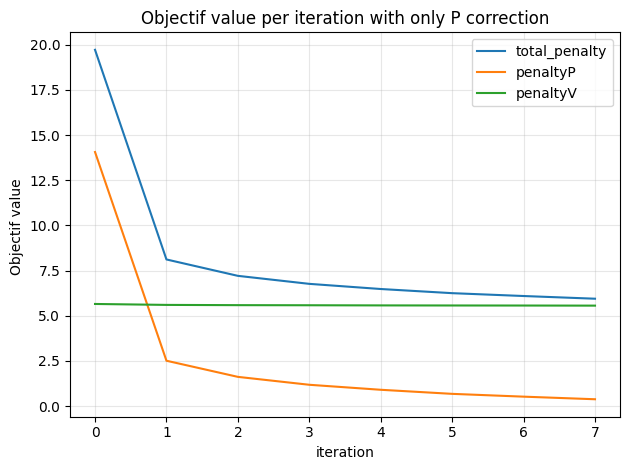

In [ ]:
plt.figure(figsize=(8, 4))
optim_info[['total_penalty', 'penaltyP', 'penaltyV']].plot()
plt.title("Objectif value per iteration with only P correction")
plt.xlabel("iteration")
plt.ylabel("Objectif value ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
optim_info

,total_penalty,penaltyP,penaltyQ,penaltyV
0,19.716704,14.061971,1.439954e-06,5.654731
1,8.117271,2.514398,4.677920e-06,5.602868
2,7.210507,1.621353,3.350107e-10,5.589154
3,6.767221,1.183784,3.501247e-09,5.583436
4,6.482178,0.906988,4.189662e-10,5.575190
5,6.252359,0.681419,5.840199e-10,5.570940
6,6.094587,0.526509,5.140620e-10,5.568078
7,5.793568,0.237827,6.175267e-09,5.555741


# TO MUCH ITERATION NOT NEEDED 

## correction 8

In [ ]:
network_name = "ieee300"
pertubation1 = "VL114_0_load_P6"
data_correction6 = pd.read_csv(
    network_name +"-corrected_" + pertubation1 + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
network = pn.load('./Outputs/' + network_name+"-corrected-"+pertubation1 + extension_in)
new_row = pd.read_csv(network_name+"-corrected_"+pertubation1+"_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_6 = data_correction6.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_6['Total_slack_abs'] = data_grouped_6['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G_6, dist, pos = network_construction(edges, data_grouped_6)
clusters = slack_subgraph(G_6, data_grouped_6)
data_grouped_6 = cluster_subgraph(G_6, clusters, data_grouped_6, dist)
fig = plot_slack_cluster(G_6, pos, clusters,data_grouped_6,data, col_centroid='centroid')
fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'ieee300-corrected_VL114_0_load_P6.csv'

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL114_0-load_P8-correction"
data_correction_9 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_9['slackValue'] = pd.to_numeric(data_correction_9['slackValue'])
data_correction_9['slackValue_pu'] = pd.to_numeric(data_correction_9['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_9 = data_correction_9.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_9['Total_slack_abs'] = data_grouped_9['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_9 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL114_0-load_P8-correction" + extension_in)
# Network construction 
G_9 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_9, data_grouped_9['slackValue'],'slack')
nx.set_node_attributes(G_9, data_grouped_9['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_9, data_grouped_9['type'],'type')
nx.set_node_attributes(G_9, data_grouped_9['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_9,data_grouped_9['gen'],'gen')
nx.set_node_attributes(G_9, data_grouped_9['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_9, data_grouped_9['transfo'],'transfo')
nx.set_node_attributes(G_9, data_grouped_9['shunt'],'shunt')
nx.set_node_attributes(G_9, data_grouped_9['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_9, seed=42)
#plot_graph(G_9, pos, '[VL1_0]').show()
clusters_9 = slack_subgraph(G_9, data_grouped_9)
subgraph_9 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_9:
    subgraph_9[comp] = G_9.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_9[comp].nodes():
        if n in data_grouped_9.index:
            node_types = data_grouped_9.loc[n, 'type']
            slack_values = data_grouped_9.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
    print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_9 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_9={}

for i,comp in enumerate(clusters_9):
    subgraph_9[comp] = G_9.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_9[i] = median(subgraph_9[comp], dist_1,data_grouped_9)
    data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'centroid'] = med_9[i][0]
    data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'centroid_2'] = med_9[i][1]
    data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_9.loc[list(subgraph_9[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_9[comp].nodes():
        if n in data_grouped_9.index:
            node_types = data_grouped_9.loc[n, 'type']
            slack_values = data_grouped_9.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_9, pos, clusters_9,data_grouped_9,data_correction_9, col_centroid='centroid')
fig.show()






























































































Component with 1 nodes: sum_P=0.023795, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.030099
Component with 1 nodes: sum_P=0.013621, sum_Q=0.000000, sum_V=0.000000
Component with 2 nodes: sum_P=0.044458, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.037505
Component with 3 nodes: sum_P=0.025872, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.023975, sum_Q=0.000000, sum_V=0.000000
Component with 3 nodes: sum_P=0.064221, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.011583, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.028941
Component with 2 nodes: sum_P=0.008424, sum_Q=0.000000, sum_V=0.000000
Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_

In [ ]:
network_9.get_loads()[network_9.get_loads()['bus_id']=='VL123_0']

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B123-L,,UNDEFINED,78.0,1.4,78.0,1.4,391.05522,VL123,VL123_0,True


## Correction 9

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL123_0-load_P9-correction"
data_correction_10 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_10['slackValue'] = pd.to_numeric(data_correction_10['slackValue'])
data_correction_10['slackValue_pu'] = pd.to_numeric(data_correction_10['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_10 = data_correction_10.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_10['Total_slack_abs'] = data_grouped_10['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_10 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL123_0-load_P9-correction" + extension_in)
# Network construction 
G_10 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_10, data_grouped_10['slackValue'],'slack')
nx.set_node_attributes(G_10, data_grouped_10['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_10, data_grouped_10['type'],'type')
nx.set_node_attributes(G_10, data_grouped_10['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_10,data_grouped_10['gen'],'gen')
nx.set_node_attributes(G_10, data_grouped_10['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_10, data_grouped_10['transfo'],'transfo')
nx.set_node_attributes(G_10, data_grouped_10['shunt'],'shunt')
nx.set_node_attributes(G_10, data_grouped_10['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_10, seed=42)
#plot_graph(G_10, pos, '[VL1_0]').show()
clusters_10 = slack_subgraph(G_10, data_grouped_10)
subgraph_10 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_10:
    subgraph_10[comp] = G_10.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_10[comp].nodes():
        if n in data_grouped_10.index:
            node_types = data_grouped_10.loc[n, 'type']
            slack_values = data_grouped_10.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
    print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_10 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_10={}

for i,comp in enumerate(clusters_10):
    subgraph_10[comp] = G_10.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_10[i] = median(subgraph_10[comp], dist_1,data_grouped_10)
    data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'centroid'] = med_10[i][0]
    data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'centroid_2'] = med_10[i][1]
    data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_10.loc[list(subgraph_10[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_10[comp].nodes():
        if n in data_grouped_10.index:
            node_types = data_grouped_10.loc[n, 'type']
            slack_values = data_grouped_10.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_10, pos, clusters_10,data_grouped_10,data_correction_10, col_centroid='centroid')
fig.show()
































































Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.001010
Component with 1 nodes: sum_P=0.019008, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.029891
Component with 1 nodes: sum_P=0.009206, sum_Q=0.000000, sum_V=0.000000
Component with 2 nodes: sum_P=0.037590, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.037050
Component with 3 nodes: sum_P=0.018161, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.021071, sum_Q=0.000000, sum_V=0.000000
Component with 2 nodes: sum_P=0.039964, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.006310, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.027649
Focal bus perturbation VL8_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL8_0', controllerE

## Correction 10 

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL123_0-load_P10-correction"
data_correction_11 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_11['slackValue'] = pd.to_numeric(data_correction_11['slackValue'])
data_correction_11['slackValue_pu'] = pd.to_numeric(data_correction_11['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_11 = data_correction_11.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_11['Total_slack_abs'] = data_grouped_11['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_11 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL123_0-load_P10-correction" + extension_in)
# Network construction 
G_11 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_11, data_grouped_11['slackValue'],'slack')
nx.set_node_attributes(G_11, data_grouped_11['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_11, data_grouped_11['type'],'type')
nx.set_node_attributes(G_11, data_grouped_11['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_11,data_grouped_11['gen'],'gen')
nx.set_node_attributes(G_11, data_grouped_11['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_11, data_grouped_11['transfo'],'transfo')
nx.set_node_attributes(G_11, data_grouped_11['shunt'],'shunt')
nx.set_node_attributes(G_11, data_grouped_11['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_11, seed=42)
#plot_graph(G_11, pos, '[VL1_0]').show()
clusters_11 = slack_subgraph(G_11, data_grouped_11)
subgraph_11 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_11:
    subgraph_11[comp] = G_11.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_11[comp].nodes():
        if n in data_grouped_11.index:
            node_types = data_grouped_11.loc[n, 'type']
            slack_values = data_grouped_11.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
    print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_11 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_11={}

for i,comp in enumerate(clusters_11):
    subgraph_11[comp] = G_11.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_11[i] = median(subgraph_11[comp], dist_1,data_grouped_11)
    data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'centroid'] = med_11[i][0]
    data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'centroid_2'] = med_11[i][1]
    data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_11.loc[list(subgraph_11[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_11[comp].nodes():
        if n in data_grouped_11.index:
            node_types = data_grouped_11.loc[n, 'type']
            slack_values = data_grouped_11.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_11, pos, clusters_11,data_grouped_11,data_correction_11, col_centroid='centroid')
fig.show()








































Component with 1 nodes: sum_P=0.015451, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.029726
Component with 1 nodes: sum_P=0.006148, sum_Q=0.000000, sum_V=0.000000
Component with 2 nodes: sum_P=0.032688, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.036564
Component with 1 nodes: sum_P=0.001092, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.018153, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.007354, sum_Q=0.000000, sum_V=0.000000
Component with 2 nodes: sum_P=0.030013, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.002712, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.026715
Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible c

In [ ]:
network_11.get_generators()[network_11.get_generators()['bus_id']=='VL92_0']

,name,energy_source,target_p,min_p,max_p,min_q,max_q,rated_s,reactive_limits_kind,target_v,target_q,voltage_regulator_on,regulated_element_id,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,,,,,,,,,,
B92-G,,OTHER,290.0,-9999.0,9999.0,-153.0,153.0,NaN,MIN_MAX,120.98,0.0,True,B92-G,-290.0,-88.464393,1398.3203,VL92,VL92_0,True


## Correction 11 

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL92_0-gen_V11-correction"
data_correction_12 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_12['slackValue'] = pd.to_numeric(data_correction_12['slackValue'])
data_correction_12['slackValue_pu'] = pd.to_numeric(data_correction_12['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_12 = data_correction_12.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_12['Total_slack_abs'] = data_grouped_12['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_12 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL92_0-gen_V11-correction" + extension_in)
# Network construction 
G_12 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_12, data_grouped_12['slackValue'],'slack')
nx.set_node_attributes(G_12, data_grouped_12['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_12, data_grouped_12['type'],'type')
nx.set_node_attributes(G_12, data_grouped_12['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_12,data_grouped_12['gen'],'gen')
nx.set_node_attributes(G_12, data_grouped_12['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_12, data_grouped_12['transfo'],'transfo')
nx.set_node_attributes(G_12, data_grouped_12['shunt'],'shunt')
nx.set_node_attributes(G_12, data_grouped_12['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_12, seed=42)
#plot_graph(G_12, pos, '[VL1_0]').show()
clusters_12 = slack_subgraph(G_12, data_grouped_12)
subgraph_12 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_12:
    subgraph_12[comp] = G_12.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_12[comp].nodes():
        if n in data_grouped_12.index:
            node_types = data_grouped_12.loc[n, 'type']
            slack_values = data_grouped_12.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
    print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_12 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_12={}

for i,comp in enumerate(clusters_12):
    subgraph_12[comp] = G_12.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_12[i] = median(subgraph_12[comp], dist_1,data_grouped_12)
    data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'centroid'] = med_12[i][0]
    data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'centroid_2'] = med_12[i][1]
    data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_12.loc[list(subgraph_12[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_12[comp].nodes():
        if n in data_grouped_12.index:
            node_types = data_grouped_12.loc[n, 'type']
            slack_values = data_grouped_12.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_12, pos, clusters_12,data_grouped_12,data_correction_12, col_centroid='centroid')
fig.show()




































Component with 1 nodes: sum_P=0.015202, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.029743
Component with 1 nodes: sum_P=0.005798, sum_Q=0.000000, sum_V=0.000000
Component with 2 nodes: sum_P=0.031467, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.004069
Component with 1 nodes: sum_P=0.017457, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.006736, sum_Q=0.000000, sum_V=0.000000
Component with 2 nodes: sum_P=0.030379, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.002743, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.026729
Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR

In [ ]:
network_12.get_generators()[network_12.get_generators()['bus_id']=='VL76_0']

,name,energy_source,target_p,min_p,max_p,min_q,max_q,rated_s,reactive_limits_kind,target_v,target_q,voltage_regulator_on,regulated_element_id,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,,,,,,,,,,
B76-G,,OTHER,0.0,-9999.0,9999.0,12.0,35.0,NaN,MIN_MAX,110.768,0.0,True,B76-G,-0.0,-65.881669,333.105425,VL76,VL76_0,True


## Correction 12

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL76_0-gen_V12-correction"
data_correction_13 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_13['slackValue'] = pd.to_numeric(data_correction_13['slackValue'])
data_correction_13['slackValue_pu'] = pd.to_numeric(data_correction_13['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_13 = data_correction_13.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_13['Total_slack_abs'] = data_grouped_13['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_13 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL76_0-gen_V12-correction" + extension_in)
# Network construction 
G_13 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_13, data_grouped_13['slackValue'],'slack')
nx.set_node_attributes(G_13, data_grouped_13['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_13, data_grouped_13['type'],'type')
nx.set_node_attributes(G_13, data_grouped_13['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_13,data_grouped_13['gen'],'gen')
nx.set_node_attributes(G_13, data_grouped_13['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_13, data_grouped_13['transfo'],'transfo')
nx.set_node_attributes(G_13, data_grouped_13['shunt'],'shunt')
nx.set_node_attributes(G_13, data_grouped_13['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_13, seed=42)
#plot_graph(G_13, pos, '[VL1_0]').show()
clusters_13 = slack_subgraph(G_13, data_grouped_13)
subgraph_13 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_13:
    subgraph_13[comp] = G_13.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_13[comp].nodes():
        if n in data_grouped_13.index:
            node_types = data_grouped_13.loc[n, 'type']
            slack_values = data_grouped_13.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
    print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_13 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_13={}

for i,comp in enumerate(clusters_13):
    subgraph_13[comp] = G_13.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_13[i] = median(subgraph_13[comp], dist_1,data_grouped_13)
    data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'centroid'] = med_13[i][0]
    data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'centroid_2'] = med_13[i][1]
    data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_13.loc[list(subgraph_13[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_13[comp].nodes():
        if n in data_grouped_13.index:
            node_types = data_grouped_13.loc[n, 'type']
            slack_values = data_grouped_13.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_13, pos, clusters_13,data_grouped_13,data_correction_13, col_centroid='centroid')
fig.show()




































Component with 1 nodes: sum_P=0.015079, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.001425
Component with 1 nodes: sum_P=0.005680, sum_Q=0.000000, sum_V=0.000000
Component with 2 nodes: sum_P=0.031117, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.004090
Component with 1 nodes: sum_P=0.017329, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.006621, sum_Q=0.000000, sum_V=0.000000
Component with 2 nodes: sum_P=0.030116, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.002622, sum_Q=0.000000, sum_V=0.000000
Component with 1 nodes: sum_P=0.000000, sum_Q=0.000000, sum_V=0.026747
Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR

In [ ]:
network_13.get_loads()[network_13.get_loads()['bus_id']=='VL528_0']

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B528-L,,UNDEFINED,5.7618,-20.5,5.7618,-20.5,105.69937,VL528,VL528_0,True


## Correction 13

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL528_0-load_P13-correction"
data_correction_14 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_14['slackValue'] = pd.to_numeric(data_correction_14['slackValue'])
data_correction_14['slackValue_pu'] = pd.to_numeric(data_correction_14['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_14 = data_correction_14.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_14['Total_slack_abs'] = data_grouped_14['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_14 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL528_0-load_P13-correction" + extension_in)
# Network construction 
G_14 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_14, data_grouped_14['slackValue'],'slack')
nx.set_node_attributes(G_14, data_grouped_14['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_14, data_grouped_14['type'],'type')
nx.set_node_attributes(G_14, data_grouped_14['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_14,data_grouped_14['gen'],'gen')
nx.set_node_attributes(G_14, data_grouped_14['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_14, data_grouped_14['transfo'],'transfo')
nx.set_node_attributes(G_14, data_grouped_14['shunt'],'shunt')
nx.set_node_attributes(G_14, data_grouped_14['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_14, seed=42)
#plot_graph(G_14, pos, '[VL1_0]').show()
clusters_14 = slack_subgraph(G_14, data_grouped_14)
subgraph_14 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_14:
    subgraph_14[comp] = G_14.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_14[comp].nodes():
        if n in data_grouped_14.index:
            node_types = data_grouped_14.loc[n, 'type']
            slack_values = data_grouped_14.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
   # print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_14 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_14={}

for i,comp in enumerate(clusters_14):
    subgraph_14[comp] = G_14.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_14[i] = median(subgraph_14[comp], dist_1,data_grouped_14)
    data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'centroid'] = med_14[i][0]
    data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'centroid_2'] = med_14[i][1]
    data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_14.loc[list(subgraph_14[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_14[comp].nodes():
        if n in data_grouped_14.index:
            node_types = data_grouped_14.loc[n, 'type']
            slack_values = data_grouped_14.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_14, pos, clusters_14,data_grouped_14,data_correction_14, col_centroid='centroid')
fig.show()
































Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus

## Correction 14 

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL123_0-load_P14-correction"
data_correction_15 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_15['slackValue'] = pd.to_numeric(data_correction_15['slackValue'])
data_correction_15['slackValue_pu'] = pd.to_numeric(data_correction_15['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_15 = data_correction_15.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_15['Total_slack_abs'] = data_grouped_15['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_15 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL123_0-load_P14-correction" + extension_in)
# Network construction 
G_15 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_15, data_grouped_15['slackValue'],'slack')
nx.set_node_attributes(G_15, data_grouped_15['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_15, data_grouped_15['type'],'type')
nx.set_node_attributes(G_15, data_grouped_15['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_15,data_grouped_15['gen'],'gen')
nx.set_node_attributes(G_15, data_grouped_15['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_15, data_grouped_15['transfo'],'transfo')
nx.set_node_attributes(G_15, data_grouped_15['shunt'],'shunt')
nx.set_node_attributes(G_15, data_grouped_15['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_15, seed=42)
#plot_graph(G_15, pos, '[VL1_0]').show()
clusters_15 = slack_subgraph(G_15, data_grouped_15)
subgraph_15 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_15:
    subgraph_15[comp] = G_15.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_15[comp].nodes():
        if n in data_grouped_15.index:
            node_types = data_grouped_15.loc[n, 'type']
            slack_values = data_grouped_15.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
   # print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_15 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_15={}

for i,comp in enumerate(clusters_15):
    subgraph_15[comp] = G_15.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_15[i] = median(subgraph_15[comp], dist_1,data_grouped_15)
    data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'centroid'] = med_15[i][0]
    data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'centroid_2'] = med_15[i][1]
    data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_15.loc[list(subgraph_15[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_15[comp].nodes():
        if n in data_grouped_15.index:
            node_types = data_grouped_15.loc[n, 'type']
            slack_values = data_grouped_15.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_15, pos, clusters_15,data_grouped_15,data_correction_15, col_centroid='centroid')
fig.show()































Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL324_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL324_0_load'])
Focal bus 

In [ ]:
network_14.get_generators()[network_14.get_generators()['bus_id']=='VL7001_2']

,name,energy_source,target_p,min_p,max_p,min_q,max_q,rated_s,reactive_limits_kind,target_v,target_q,voltage_regulator_on,regulated_element_id,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,,,,,,,,,,
B7003-G,,OTHER,1210.0,-9999.0,9999.0,-420.0,420.0,NaN,MIN_MAX,16.52994,0.0,True,B7003-G,-1210.0,-2096.303959,82724.909595,VL7001,VL7001_2,True


## Correction 15

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL7001_2-gen_V15-correction"
data_correction_16 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_16['slackValue'] = pd.to_numeric(data_correction_16['slackValue'])
data_correction_16['slackValue_pu'] = pd.to_numeric(data_correction_16['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_16 = data_correction_16.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_16['Total_slack_abs'] = data_grouped_16['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_16 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL7001_2-gen_V15-correction" + extension_in)
# Network construction 
G_16 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_16, data_grouped_16['slackValue'],'slack')
nx.set_node_attributes(G_16, data_grouped_16['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_16, data_grouped_16['type'],'type')
nx.set_node_attributes(G_16, data_grouped_16['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_16,data_grouped_16['gen'],'gen')
nx.set_node_attributes(G_16, data_grouped_16['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_16, data_grouped_16['transfo'],'transfo')
nx.set_node_attributes(G_16, data_grouped_16['shunt'],'shunt')
nx.set_node_attributes(G_16, data_grouped_16['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_16, seed=42)
#plot_graph(G_15, pos, '[VL1_0]').show()
clusters_16 = slack_subgraph(G_16, data_grouped_16)
subgraph_16 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_16:
    subgraph_16[comp] = G_16.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_16[comp].nodes():
        if n in data_grouped_16.index:
            node_types = data_grouped_16.loc[n, 'type']
            slack_values = data_grouped_16.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
   # print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_16 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_16={}

for i,comp in enumerate(clusters_16):
    subgraph_16[comp] = G_16.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_16[i] = median(subgraph_16[comp], dist_1,data_grouped_16)
    data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'centroid'] = med_16[i][0]
    data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'centroid_2'] = med_16[i][1]
    data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_16.loc[list(subgraph_16[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_16[comp].nodes():
        if n in data_grouped_16.index:
            node_types = data_grouped_16.loc[n, 'type']
            slack_values = data_grouped_16.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_16, pos, clusters_16,data_grouped_16,data_correction_16, col_centroid='centroid')
fig.show()































Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL324_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL324_0_load'])
Focal bus 

## Correction 16

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL123_0-load_P16-correction"
data_correction_17 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_17['slackValue'] = pd.to_numeric(data_correction_17['slackValue'])
data_correction_17['slackValue_pu'] = pd.to_numeric(data_correction_17['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_17 = data_correction_17.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_17['Total_slack_abs'] = data_grouped_17['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_17 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL123_0-load_P16-correction" + extension_in)
# Network construction 
G_17 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_17, data_grouped_17['slackValue'],'slack')
nx.set_node_attributes(G_17, data_grouped_17['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_17, data_grouped_17['type'],'type')
nx.set_node_attributes(G_17, data_grouped_17['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_17,data_grouped_17['gen'],'gen')
nx.set_node_attributes(G_17, data_grouped_17['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_17, data_grouped_17['transfo'],'transfo')
nx.set_node_attributes(G_17, data_grouped_17['shunt'],'shunt')
nx.set_node_attributes(G_17, data_grouped_17['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_17, seed=42)
#plot_graph(G_15, pos, '[VL1_0]').show()
clusters_17 = slack_subgraph(G_17, data_grouped_17)
subgraph_17 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_17:
    subgraph_17[comp] = G_17.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_17[comp].nodes():
        if n in data_grouped_17.index:
            node_types = data_grouped_17.loc[n, 'type']
            slack_values = data_grouped_17.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
   # print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_17 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_17={}

for i,comp in enumerate(clusters_17):
    subgraph_17[comp] = G_17.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_17[i] = median(subgraph_17[comp], dist_1,data_grouped_17)
    data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'centroid'] = med_17[i][0]
    data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'centroid_2'] = med_17[i][1]
    data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_17.loc[list(subgraph_17[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_17[comp].nodes():
        if n in data_grouped_17.index:
            node_types = data_grouped_17.loc[n, 'type']
            slack_values = data_grouped_17.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_17, pos, clusters_17,data_grouped_17,data_correction_17, col_centroid='centroid')
fig.show()

















Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL324_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL324_0_load'])
Focal bus perturbation VL123_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL123_0_load'])
Focal bus perturbation VL7001_2 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL7001_2', controllerElem

In [ ]:
network_17.get_loads()[network_17.get_loads()['bus_id']=='VL324_0']

,name,type,p0,q0,p,q,i,voltage_level_id,bus_id,connected
id,,,,,,,,,,
B324-L,,UNDEFINED,24.7,-1.2,24.7,-1.2,127.213876,VL324,VL324_0,True


## Correction 17

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL324_0-load_P17-correction"
data_correction_18 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_18['slackValue'] = pd.to_numeric(data_correction_18['slackValue'])
data_correction_18['slackValue_pu'] = pd.to_numeric(data_correction_18['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_18 = data_correction_18.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_18['Total_slack_abs'] = data_grouped_18['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_18 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL324_0-load_P17-correction" + extension_in)
# Network construction 
G_18 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_18, data_grouped_18['slackValue'],'slack')
nx.set_node_attributes(G_18, data_grouped_18['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_18, data_grouped_18['type'],'type')
nx.set_node_attributes(G_18, data_grouped_18['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_18,data_grouped_18['gen'],'gen')
nx.set_node_attributes(G_18, data_grouped_18['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_18, data_grouped_18['transfo'],'transfo')
nx.set_node_attributes(G_18, data_grouped_18['shunt'],'shunt')
nx.set_node_attributes(G_18, data_grouped_18['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_18, seed=42)
#plot_graph(G_15, pos, '[VL1_0]').show()
clusters_18 = slack_subgraph(G_18, data_grouped_18)
subgraph_18 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_18:
    subgraph_18[comp] = G_18.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_18[comp].nodes():
        if n in data_grouped_18.index:
            node_types = data_grouped_18.loc[n, 'type']
            slack_values = data_grouped_18.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
   # print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_18 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_18={}

for i,comp in enumerate(clusters_18):
    subgraph_18[comp] = G_18.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_18[i] = median(subgraph_18[comp], dist_1,data_grouped_18)
    data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'centroid'] = med_18[i][0]
    data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'centroid_2'] = med_18[i][1]
    data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_18.loc[list(subgraph_18[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_18[comp].nodes():
        if n in data_grouped_18.index:
            node_types = data_grouped_18.loc[n, 'type']
            slack_values = data_grouped_18.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_18, pos, clusters_18,data_grouped_18,data_correction_18, col_centroid='centroid')
fig.show()

















Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL324_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL324_0_load'])
Focal bus perturbation VL123_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL123_0_load'])
Focal bus perturbation VL7001_2 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL7001_2', controllerElem

## Correction 18 

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL123_0-load_P18-correction"
data_correction_19 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_19['slackValue'] = pd.to_numeric(data_correction_19['slackValue'])
data_correction_19['slackValue_pu'] = pd.to_numeric(data_correction_19['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_19 = data_correction_19.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_19['Total_slack_abs'] = data_grouped_19['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_19 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL123_0-load_P18-correction" + extension_in)
# Network construction 
G_19 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_19, data_grouped_19['slackValue'],'slack')
nx.set_node_attributes(G_19, data_grouped_19['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_19, data_grouped_19['type'],'type')
nx.set_node_attributes(G_19, data_grouped_19['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_19,data_grouped_19['gen'],'gen')
nx.set_node_attributes(G_19, data_grouped_19['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_19, data_grouped_19['transfo'],'transfo')
nx.set_node_attributes(G_19, data_grouped_19['shunt'],'shunt')
nx.set_node_attributes(G_19, data_grouped_19['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_19, seed=42)
#plot_graph(G_15, pos, '[VL1_0]').show()
clusters_19 = slack_subgraph(G_19, data_grouped_19)
subgraph_19 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_19:
    subgraph_19[comp] = G_19.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_19[comp].nodes():
        if n in data_grouped_19.index:
            node_types = data_grouped_19.loc[n, 'type']
            slack_values = data_grouped_19.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
   # print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_19 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_19={}

for i,comp in enumerate(clusters_19):
    subgraph_19[comp] = G_19.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_19[i] = median(subgraph_19[comp], dist_1,data_grouped_19)
    data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'centroid'] = med_19[i][0]
    data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'centroid_2'] = med_19[i][1]
    data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_19.loc[list(subgraph_19[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_19[comp].nodes():
        if n in data_grouped_19.index:
            node_types = data_grouped_19.loc[n, 'type']
            slack_values = data_grouped_19.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_19, pos, clusters_19,data_grouped_19,data_correction_19, col_centroid='centroid')
fig.show()

















Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL324_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL324_0_load'])
Focal bus perturbation VL123_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL123_0_load'])
Focal bus perturbation VL7001_2 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL7001_2', controllerElem

## Correction 19 

In [ ]:
network_name = "ieee300"
pertubation = "corrected_VL123_0-load_P19-correction"
data_correction_20 = pd.read_csv(
    network_name + "-" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)

data_correction_20['slackValue'] = pd.to_numeric(data_correction_20['slackValue'])
data_correction_20['slackValue_pu'] = pd.to_numeric(data_correction_20['slackValue_pu'])

# Custom aggregation function that removes duplicates while preserving order

data_grouped_20 = data_correction_20.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_20['Total_slack_abs'] = data_grouped_20['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
network_20 = pn.load('./Outputs/' + network_name+"-"+"corrected-VL123_0-load_P19-correction" + extension_in)
# Network construction 
G_20 = nx.from_pandas_edgelist(edges_list,'bus1_id','bus2_id', edge_attr=True,create_using=nx.Graph())
# ?? nécessaire ? car très lent sur les gros réseaux ?? implémenter que sur les noeds ayant une slack (comme dist)
nx.set_node_attributes(G_20, data_grouped_20['slackValue'],'slack')
nx.set_node_attributes(G_20, data_grouped_20['slackValue_pu'],'slack_pu')
nx.set_node_attributes(G_20, data_grouped_20['type'],'type')
nx.set_node_attributes(G_20, data_grouped_20['Total_slack_abs'],'Total_slack_abs')
nx.set_node_attributes(G_20,data_grouped_20['gen'],'gen')
nx.set_node_attributes(G_20, data_grouped_20['controlevoltage'],'controlevoltage')
nx.set_node_attributes(G_20, data_grouped_20['transfo'],'transfo')
nx.set_node_attributes(G_20, data_grouped_20['shunt'],'shunt')
nx.set_node_attributes(G_20, data_grouped_20['load'],'load')

#pertubation = [n for n in G.nodes if n in G_slack.nodes]
pos = nx.spring_layout(G_20, seed=42)
#plot_graph(G_15, pos, '[VL1_0]').show()
clusters_20 = slack_subgraph(G_20, data_grouped_20)
subgraph_20 = {}
sum_p = {}
sum_q = {}
sum_v = {}
i =0 
for comp in clusters_20:
    subgraph_20[comp] = G_20.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0

    data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'cluster_id'] = i


    for n in subgraph_20[comp].nodes():
        if n in data_grouped_20.index:
            node_types = data_grouped_20.loc[n, 'type']
            slack_values = data_grouped_20.loc[n, 'slackValue_pu']

            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += np.abs(slack_val)
                    elif node_type == 'Q':
                        sum_q[comp] += np.abs(slack_val)
                    elif node_type == 'V':
                        sum_v[comp] += np.abs(slack_val)

    if sum_p[comp]>sum_q[comp] and sum_p[comp]>sum_v[comp]:
        data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'dominant_slack'] = 'P'
    elif sum_q[comp]>sum_p[comp] and sum_q[comp]>sum_v[comp]:
        data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'dominant_slack'] = 'Q'
    elif sum_v[comp]>sum_p[comp] and sum_v[comp]>sum_q[comp]:
        data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'dominant_slack'] = 'V'

    data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'sum_P'] = sum_p[comp]
    data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'sum_Q'] = sum_q[comp]
    data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'sum_V'] = sum_v[comp]
    i+=1
   # print(f"Component with {len(comp)} nodes: sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
subgraph_20 = {}
sum_p = {}
sum_q = {}
sum_v = {}
med_20={}

for i,comp in enumerate(clusters_20):
    subgraph_20[comp] = G_20.subgraph(comp)
    sum_p[comp] = 0
    sum_q[comp] = 0
    sum_v[comp] = 0
    med_20[i] = median(subgraph_20[comp], dist_1,data_grouped_20)
    data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'centroid'] = med_20[i][0]
    data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'centroid_2'] = med_20[i][1]
    data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'cluster_size'] = len(comp)
    data_grouped_20.loc[list(subgraph_20[comp].nodes()), 'cluster_id'] = i
    
    for n in subgraph_20[comp].nodes():
        if n in data_grouped_20.index:
            node_types = data_grouped_20.loc[n, 'type']
            slack_values = data_grouped_20.loc[n, 'slackValue_pu']

            # Handle list of types and slack values
            if isinstance(node_types, list) and isinstance(slack_values, list):
                for node_type, slack_val in zip(node_types, slack_values):
                    if node_type == 'P':
                        sum_p[comp] += slack_val
                    elif node_type == 'Q':
                        sum_q[comp] += slack_val
                    elif node_type == 'V':
                        sum_v[comp] += slack_val
    #print(f"Component with {len(comp)} nodes: center={med_4[i]}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    
fig = plot_slack_components(G_20, pos, clusters_20,data_grouped_20,data_correction_20, col_centroid='centroid')
fig.show()












Focal bus perturbation VL27_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL27_0_load'])
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL324_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL324_0_load'])
Focal bus perturbation VL123_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL123_0_load'])
Focal bus perturbation VL7001_2 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL7001_2', controllerElements=

## Correction 20

# BROUILLON

In [ ]:
# cluster_2nd_all = slack_subgraph_2nd(G, data_grouped)
# cluster_2nd = slack_subgraph_2nd(G, data_grouped)

# # Include neighbour nodes that have no slack into the clusters
# expanded = []
# for comp in cluster_2nd_all:
#     comp_set = set(comp)
#     to_add = set()
#     for n in list(comp_set):
#         for nbr in G.neighbors(n):
#             if nbr not in comp_set and not has_slack(G, nbr, data_grouped):
#                 to_add.add(nbr)
#     comp_set |= to_add
#     expanded.append(frozenset(comp_set))

# # Merge overlapping clusters that may result from adding neighbours
# merged = [set(c) for c in expanded]
# changed = True
# while changed:
#     changed = False
#     out = []
#     while merged:
#         first = merged.pop(0)
#         rest = []
#         for other in merged:
#             if first & other:
#                 first |= other
#                 changed = True
#             else:
#                 rest.append(other)
#         out.append(first)
#         merged = rest
#     merged = out

# cluster_2nd_all = [frozenset(s) for s in merged]


# 2nd degree

In [ ]:
# def has_attr(G, n, attr):
#     return G.nodes[n].get(attr, False)

# def has_slack(G, n, data_grouped):
#     return G.nodes[n].get("slack", False)

# def dfs_distance1(G, source, attr):
#     visited = set()
#     stack = [source]
#     cluster_nodes = []

#     while stack:
#         u = stack.pop()
#         if u not in visited:
#             visited.add(u)
#             cluster_nodes.append(u)

#         # 1) direct neighbors with attribute
#         for v in G.neighbors(u):
#             if v not in visited and has_slack(G, v, data_grouped):
#                 stack.append(v)
#             elif not has_slack(G, v, data_grouped) and v not in visited:
#                 if v not in cluster_nodes:
#                     cluster_nodes.append(v)

#         # 2) neighbors of neighbors (distance 1 expansion)
#         # for v in G.neighbors(u):
#         #     for w in G.neighbors(v):
#         #         if w not in visited and has_attr(G, w, attr):
#         #             stack.append(w)

#     return cluster_nodes

# def slack_clusters_with_neighbors(G, data_grouped):
#     seen = set()
#     clusters = []

#     for n in G.nodes():
#         if not has_slack(G, n, data_grouped):
#             continue

#         comp = dfs_distance1(G, n, data_grouped)
#         key = frozenset(comp)

#         if key not in seen:
#             seen.add(key)
#             clusters.append(comp)

#     return clusters



In [ ]:
# # def slack_subgraph_2nd(G, data_grouped):
# #     seen = set()  
# #     components = []

# #     for n in G.nodes():
# #         if not has_slack(G, n, data_grouped):
# #             continue

# #         comp = frozenset(dfs_slack_2nd(G, n, data_grouped))

# #         if comp not in seen:
# #             seen.add(comp)
# #             components.append(comp)

# #     return components

# # def slack_subgraph_2nd(G, data_grouped):
# #     seen = set()
# #     components = []

# #     for n in G.nodes():
# #         if not has_slack(G, n, data_grouped):
# #             continue

# #         visited = dfs_slack_2nd(G, n, data_grouped)  # <-- LISTE ordonnée
# #         comp_key = frozenset(visited)                # <-- clé pour éviter doublons

# #         if comp_key not in seen:
# #             seen.add(comp_key)
# #             components.append(visited)               # <-- on garde la LISTE
# #     return components

# def dfs_slack_2nd(G, source, data_grouped):
#     visited = set([source]) # list et pas set ordonnée par précédence pour pouvoir ajouter / retenir ordre de précédence 
#     stack = [source] 
#     while stack:
#         u = stack.pop()
#        # print(f"Visiting node {u}")
#         for v in G.neighbors(u):
#           #  print(f"Visiting neighbor {v} of {u}")
#             if v in visited:
#                # print(f"Neighbor {v} already visited")
#                 continue
            
#             if has_slack(G, v, data_grouped): 
#            #     print(f"Neighbor {v} has slack, adding to visited and stack")
#                 visited.add(v)
#                 stack.append(v)
#             #    print(f"Added {v} to visited and stack")
#             # if not has_slack(G,v,data_grouped):
#             #     z = dfs_with_slack(G, v, data_grouped)
#             #     print(f"DFS from {v} found nodes: {z}")
#             #     if z - visited:  # Only proceed if there are new nodes in z
#             #         visited.update(z)
#             #         stack.extend(z)
#             #     # visited.add(v)
#             #     # stack.append(v)
#             #if not has_slack(G, v, data_grouped):
#             else :
#                 for neighbor in G.neighbors(v):
#                     if neighbor in visited:
#                    # print(f"Neighbor {neighbor} already visited, skipping")
#                         continue
#                     if has_slack(G, neighbor, data_grouped):
#                    # print(f"Neighbor {neighbor} of {v} has slack, adding to visited and stack")
#                         visited.add(neighbor)
#                         stack.append(neighbor)
#                         ## refaire un 
#                       #  visited.add(v)
#                         stack.append(v)
#                        # visited.add(v)
#                     else: 
#                         continue
#                         # print(f"Added {neighbor} to visited and stack from {v}")
#                     # if not has_slack(G, neighbor, data_grouped):
#                     #     continue
#             #print(f"Finished visiting {u}, current visited list: {visited}")

#     return visited

In [ ]:
# def merge_overlapping_clusters(clusters, overlap_threshold=0.9):
#     """
#     Merge clusters that have significant overlap.
    
#     Args:
#         clusters: list of frozensets
#         overlap_threshold: minimum Jaccard similarity to merge (default 0.9)
#     """
#     parent = {}
    
#     def find(x):
#         parent.setdefault(x, x)
#         if parent[x] != x:
#             parent[x] = find(parent[x])
#         return parent[x]
    
#     def union(a, b):
#         ra, rb = find(a), find(b)
#         if ra != rb:
#             parent[rb] = ra
    
#     # Calculate overlap between all pairs
#     cluster_list = list(clusters)
#     for i in range(len(cluster_list)):
#         for j in range(i + 1, len(cluster_list)):
#             c1, c2 = cluster_list[i], cluster_list[j]
#             intersection = len(c1 & c2)
#             union_size = len(c1 | c2)
            
#             # Jaccard similarity
#             similarity = intersection / union_size if union_size > 0 else 0
            
#             if similarity >= overlap_threshold:
#                 union(c1, c2)
    
#     # Merge clusters with same parent
#     merged = {}
#     for comp in clusters:
#         root = find(comp)
#         merged.setdefault(root, set()).update(comp)
    
#     return [frozenset(nodes) for nodes in merged.values()]

In [ ]:

# def dfs_slack_2nd(G, source, data_grouped):
#     visited = set([source]) # list et pas set ordonnée par précédence pour pouvoir ajouter / retenir ordre de précédence 
#     stack = [source] 
#     while stack:
#         u = stack.pop()
#        # print(f"Visiting node {u}")
#         for v in G.neighbors(u):
#           #  print(f"Visiting neighbor {v} of {u}")
#             if v in visited:
#                # print(f"Neighbor {v} already visited")
#                 continue
            
#             if has_slack(G, v, data_grouped): 
#            #     print(f"Neighbor {v} has slack, adding to visited and stack")
#                 visited.add(v)
#                 stack.append(v)

#             else :
#                 for neighbor in G.neighbors(v):
#                     if neighbor in visited:
#                 #    # print(f"Neighbor {neighbor} already visited, skipping")
#                         continue
#                     if has_slack(G, neighbor, data_grouped):
#                    # print(f"Neighbor {neighbor} of {v} has slack, adding to visited and stack")
#                         visited.add(neighbor)
#                         stack.append(neighbor)
#                         ## refaire un 
#                       #  visited.add(v)
#                         #stack.append(v)
#                         visited.add(v)
#                     else: 
#                         continue
#                        # stack.append(v)
#                        # visited.add(neighbor)
#                        # visited.add(v)
#                         # print(f"Added {neighbor} to visited and stack from {v}")
#                     # if not has_slack(G, neighbor, data_grouped):
#                     #     continue
#             #print(f"Finished visiting {u}, current visited list: {visited}")

#     return visited

# result1 = dfs_slack_2nd(G, 'VL324_0', data_grouped)
# result2 = dfs_slack_2nd(G, 'VL562_0', data_grouped)

# print(f"dfs_slack_2nd result 77: {result1}")
# print(f"dfs_slack_2nd result 609: {result2}")
# print(f"Difference: {result1.symmetric_difference(result2)}")

In [ ]:
# # Nodes in result from VL609_0 but not in result from VL77_0
# difference_1_minus_2 = result1 - result2
# # Output: {'VL7139_0', 'VL172_0', 'VL173_0', 'VL139_0', 'VL175_0', 'VL182_0'}

# # Nodes in result from VL77_0 but not in result from VL609_0  
# difference_2_minus_1 = result2 - result1
# # Output: set() (empty)

# # Symmetric difference (nodes in either but not both)
# symmetric_diff = result1.symmetric_difference(result2)
# print(f"Symmetric difference: {symmetric_diff}")
# # Output: {'VL7139_0', 'VL172_0', 'VL173_0', 'VL139_0', 'VL175_0', 'VL182_0'}

# # Are they equal?
# print(f"Are equal: {result1 == result2}")
# print(len(result1), len(result2))
# # Output: False

In [ ]:
# cluster = []
# seen = set()

# for n in G.nodes():
#     if not has_slack(G, n, data_grouped):
#         continue
    
#     # Get the cluster starting from this node
#     maybe_cluster = frozenset(dfs_slack_2nd(G, n, data_grouped))
    
#     # Only add if we haven't seen this cluster before
#     if maybe_cluster not in seen:
#         seen.add(maybe_cluster)
#         cluster.append(maybe_cluster)
# #cluster = merge_overlapping_clusters(cluster, overlap_threshold=0.9)


In [ ]:
# cluster = []
# seen = set()

# for n in G.nodes():
#     if not has_slack(G, n, data_grouped):
#         continue
    
#     # Get the cluster starting from this node
#     maybe_cluster = frozenset(dfs_slack_2nd(G, n, data_grouped))
    
#     # Only add if:
#     # 1. We haven't seen this cluster before
#     # 2. There's at least one node with slack in the cluster
#     if maybe_cluster not in seen:# and any(has_slack(G, node, data_grouped) for node in maybe_cluster):
#         seen.add(maybe_cluster)
#         cluster.append(maybe_cluster)

In [ ]:
# u = dfs_slack_2nd(G, 'VL175_0', data_grouped)
# med_u = median_strict(G.subgraph(u), u, weight="impedance_module", data=data_grouped)

In [ ]:
# from utils import median_strict

# for comp in cluster:
#     med = median_strict(G.subgraph(comp), comp, weight="impedance_module", data=data_grouped)
#     print(f"Cluster with {len(comp)} nodes: centroid  is {med}, {comp}")

In [ ]:
# import networkx as nx

# def has_attr(G, n, attr):
#     """Retourne True si le nœud possède l'attribut."""
#     return bool(G.nodes[n].get(attr, False))


# def dfs_fusion_attr(G, source, attr):
#     """
#     DFS qui traverse uniquement les nœuds ayant l'attribut,
#     mais ajoute aussi les voisins qui ne l'ont pas.
#     """
#     visited_attr = set()      # nœuds avec attribut (pour la propagation)
#     cluster = []              # tous les nœuds du cluster (ordre conservé)
#     stack = [source]

#     while stack:
#         u = stack.pop()

#         if u not in visited_attr:
#             visited_attr.add(u)
#             if u not in cluster:
#                 cluster.append(u)

#         for v in G.neighbors(u):

#             # Si le voisin a l'attribut → on propage
#             if has_attr(G, v, attr) and v not in visited_attr:
#                 stack.append(v)

#             # Si le voisin n'a pas l'attribut → on l'ajoute mais on ne propage pas
#             elif not has_attr(G, v, attr):
#                 if v not in cluster:
#                     cluster.append(v)

#     return cluster


# def fusion_clusters_attr(G, attr):
#     """
#     Retourne une liste de clusters fusionnés selon l'attribut.
#     """
#     seen = set()
#     clusters = []

#     for n in G.nodes():
#         if not has_attr(G, n, attr):
#             continue

#         comp = dfs_fusion_attr(G, n, attr)
#         key = frozenset(comp)

#         if key not in seen:
#             seen.add(key)
#             clusters.append(comp)

#     return clusters


In [ ]:
# clusters = fusion_clusters_attr(G, attr="slack")
# for c in clusters:
#     print("Cluster :", c)


In [ ]:
# subgraph = {}
# sum_p = {}
# sum_q = {}
# sum_v = {}

# for comp in clusters:
#     if isinstance(comp, list):
#         comp = frozenset(comp)
#     subgraph[comp] = G.subgraph(comp)
#     sum_p[comp] = 0
#     sum_q[comp] = 0
#     sum_v[comp] = 0
#     med = median_strict(subgraph[comp], subgraph[comp].nodes(), weight="impedance_module", data=data_grouped)

#     for n in subgraph[comp].nodes():
#         if n in data_grouped.index:
#             node_types = data_grouped.loc[n, 'type']
#             slack_values = data_grouped.loc[n, 'slackValue_pu']
            
#             data_grouped.loc[n, 'centroid_2'] = med
#             data_grouped.loc[n, 'cluster_size_2'] = len(comp)
    
            
#             # Handle list of types and slack values
#             if isinstance(node_types, list) and isinstance(slack_values, list):
#                 for node_type, slack_val in zip(node_types, slack_values):
#                     if node_type == 'P':
#                         sum_p[comp] += slack_val
#                     elif node_type == 'Q':
#                         sum_q[comp] += slack_val
#                     elif node_type == 'V':
#                         sum_v[comp] += slack_val
#     print(f"Component with {len(comp)} nodes: center={med}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

In [ ]:
# centroid = data_grouped.groupby('centroid_2').apply(
# 	lambda x: builtins.sum(
# 		builtins.sum(v) if isinstance(v, list) else v
# 		for v in x["Total_slack_abs"]
# 	)
#     )

# centroid

In [ ]:
# fig = plot_slack_components(G, pos, clusters,data_grouped,data, col_centroid='centroid_2')
# fig.show()

In [ ]:
# subgraph = {}
# sum_p = {}
# sum_q = {}
# sum_v = {}

# for comp in cluster_2nd_all:
#     subgraph[comp] = G.subgraph(comp)
#     sum_p[comp] = 0.0
#     sum_q[comp] = 0.0
#     sum_v[comp] = 0.0
#     med = median_strict(subgraph[comp], subgraph[comp].nodes(), weight="impedance_module", data=data_grouped)
#     nodes = list(subgraph[comp].nodes())

#     # ensure rows exist for nodes in this component to avoid KeyError on .loc
#     existing_nodes = [n for n in nodes if n in data_grouped.index]
#     missing = [n for n in nodes if n not in data_grouped.index]
#     if missing:
#         # create missing rows with safe defaults for expected columns
#         defaults = {
#             'controlevoltage': None,
#             'slackValue_pu': 0.0,
#             'slackValue': 0.0,
#             'Total_slack_abs': 0.0,
#             'type': None,
#             'gen': None,
#             'transfo': None,
#             'shunt': None,
#             'load': None
#         }
#         for n in missing:
#             # only set columns present in data_grouped to avoid mismatched columns
#             row = {c: defaults.get(c, np.nan) for c in data_grouped.columns}
#             data_grouped.loc[n] = row
#         existing_nodes = [n for n in nodes if n in data_grouped.index]

#     # ensure centroid row exists (create if missing)
#     if med not in data_grouped.index:
#         data_grouped.loc[med, ['cluster_size_2nd', 'centroid_2nd']] = [len(comp), med]
#     else:
#         # assign centroid/cluster_size only for nodes that exist in index
#         if existing_nodes:
#             data_grouped.loc[existing_nodes, 'centroid_2nd'] = med
#             data_grouped.loc[existing_nodes, 'cluster_size_2nd'] = len(comp)

#     for n in subgraph[comp].nodes():
#         if n in data_grouped.index:
#             node_types = data_grouped.at[n, 'type']
#             slack_values = data_grouped.at[n, 'slackValue_pu']

#             # Normalize slack_values to a float or list
#             if isinstance(slack_values, list):
#                 slack_list = slack_values
#             else:
#                 slack_list = [slack_values]

#             # Handle node_types being list or scalar
#             if isinstance(node_types, list):
#                 # pair types with slack values if possible, otherwise reuse single slack
#                 for i, node_type in enumerate(node_types):
#                     val = slack_list[i] if i < len(slack_list) else slack_list[0]
#                     try:
#                         val = float(val)
#                     except Exception:
#                         continue
#                     if node_type == 'P':
#                         sum_p[comp] += val
#                     elif node_type == 'Q':
#                         sum_q[comp] += val
#                     elif node_type == 'V':
#                         sum_v[comp] += val
#             else:
#                 # single type
#                 try:
#                     val = float(slack_list[0]) if slack_list else 0.0
#                 except Exception:
#                     val = 0.0
#                 if node_types == 'P':
#                     sum_p[comp] += val
#                 elif node_types == 'Q':
#                     sum_q[comp] += val
#                 elif node_types == 'V':
#                     sum_v[comp] += val

#     print(f"Component with {len(comp)} nodes: center={med}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    

In [ ]:
# from utils import plot_slack_components_2nd
# fig = plot_slack_components_2nd(G, pos, cluster_2nd_all,data_grouped, col_centroid='centroid_2nd')
# fig.show()

# Cluster per type of slack 

In [ ]:
# def has_type_P(G, v, data_grouped):
#     if v in data_grouped.index:
#         slack_type = data_grouped.loc[v, 'type']
#         print(f"Node {v} has type {slack_type}")    
#         if isinstance(slack_type, list):
#             return 'P' in slack_type
   
#     else:
#         node_slack = G.nodes[v].get('slack', None)
#         return node_slack not in (None, 'N/A')
    

    
# def has_type_Q(G, v, data_grouped):
#     if v in data_grouped.index:
#         slack_type = data_grouped.loc[v, 'type']
#         print(f"Node {v} has type {slack_type}")    
#         if isinstance(slack_type, list):
#             return 'Q' in slack_type

# def has_type_V(G, v, data_grouped):
#     if v in data_grouped.index:
#         slack_type = data_grouped.loc[v, 'type']
#         print(f"Node {v} has type {slack_type}")    
#         if isinstance(slack_type, list):
#             return 'V' in slack_type
   
#     else:
#         node_slack = G.nodes[v].get('slack', None)
#         return node_slack not in (None, 'N/A')
    

In [ ]:
# def dfs_with_slack_P(G, source, data_grouped):
#     visited = set([source])
#     stack = [source]
#     while stack:
#         u = stack.pop()

#         for v in G.neighbors(u):
#             if v in visited:
#                 continue

#             if not has_slack(G, v, data_grouped) or not has_type_P(G, v, data_grouped):
#                 continue
#             visited.add(v)
#             stack.append(v)

#     return visited


In [ ]:
# def slack_subgraph_P(G, data_grouped):
#     seen = set()
#     components = []

#     for n in G.nodes():
#         if not has_slack(G, n, data_grouped) or not has_type_P(G, n, data_grouped):
#             continue

#         comp = frozenset(dfs_with_slack_P(G, n, data_grouped))

#         if comp not in seen:
#             seen.add(comp)
#             components.append(comp)

#     return components

# def slack_subgraph_Q(G, data_grouped):
#     seen = set()
#     components = []

#     for n in G.nodes():
#         if not has_slack(G, n, data_grouped) or not has_type_Q(G, n, data_grouped):
#             continue

#         comp = frozenset(dfs_with_slack_Q(G, n, data_grouped))

#         if comp not in seen:
#             seen.add(comp)
#             components.append(comp)

#     return components

# def slack_subgraph_V(G, data_grouped):
#     seen = set()
#     components = []

#     for n in G.nodes():
#         if not has_slack(G, n, data_grouped) or not has_type_V(G, n, data_grouped):
#             continue

#         comp = frozenset(dfs_with_slack_V(G, n, data_grouped))

#         if comp not in seen:
#             seen.add(comp)
#             components.append(comp)

#     return components

In [ ]:
# subgraph = {}
# sum_p = {}
# sum_q = {}
# sum_v = {}

# for comp in cluster_P:
#     subgraph[comp] = G.subgraph(comp)
#     sum_p[comp] = 0
#     sum_q[comp] = 0
#     sum_v[comp] = 0
#     med = median_strict(subgraph[comp], subgraph[comp].nodes(), weight="impedance_module", data=data_grouped)
#     nodes = list(subgraph[comp].nodes())
#     # create missing rows for nodes not in data_grouped to avoid KeyError
#     # missing = [n for n in nodes if n not in data_grouped.index]
#     # if missing:
#     #     data_grouped.loc[missing, ['controlevoltage', 'slackValue_pu', 'Total_slack_abs', 'type']] = [None, 0.0, 0.0, None]

#     # ensure centroid node exists
#     if med not in data_grouped.index:
#         data_grouped.loc[med, ['cluster_size_P', 'centroid_P']] = [len(comp), med]

#     elif med in data_grouped.index:
#         data_grouped.loc[nodes, 'centroid_P'] = med 
#         data_grouped.loc[list(subgraph[comp].nodes()), 'cluster_size_P'] = len(comp)


#     for n in subgraph[comp].nodes():
#         if n in data_grouped.index:
#             node_types = data_grouped.loc[n, 'type']
#             slack_values = data_grouped.loc[n, 'slackValue_pu']
            
#             # Handle list of types and slack values
#             if isinstance(node_types, list) and isinstance(slack_values, list):
#                 for node_type, slack_val in zip(node_types, slack_values):
#                     if node_type == 'P':
#                         sum_p[comp] += slack_val
#                     elif node_type == 'Q':
#                         sum_q[comp] += slack_val
#                     elif node_type == 'V':
#                         sum_v[comp] += slack_val
#     print(f"Component with {len(comp)} nodes: center={med}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")


In [ ]:
# def plot_slack_type(G, pos, clusters_P, cluster_Q, cluster_V, data_grouped):
#     # Color cycle for components
#     base_colors = ["red", "blue", "green"]
#      #   "brown", "cyan", "magenta", "olive", "teal", "pink", "gold", "navy","violet"]
#     colors = itertools.cycle(base_colors)

#     fig = go.Figure()

#     edge_x_all = []
#     edge_y_all = []
#     edge_info_all = []

#     for u, v, d in G.edges(data=True):
#             edge_x_all += [pos[u][0], pos[v][0], None]
#             edge_y_all += [pos[u][1], pos[v][1], None]
#             txt = f"{d.get('type')}"
#             edge_info_all += [txt, None]

#     fig.add_trace(go.Scatter(
#         x=edge_x_all, y=edge_y_all,
#         mode="lines",
#         line=dict(width=0.5, color="grey"),
#         text=edge_info_all,
#         hovertemplate="%{text}<extra></extra>",
#         name="edges"
#         ))
    
#     node_x_all = [pos[n][0] for n in G.nodes() if not has_slack(G, n, data_grouped)]
#     node_y_all = [pos[n][1] for n in G.nodes() if not has_slack(G, n, data_grouped)]
#     hover_all = [f"Node: {n}" for n in G.nodes() if not has_slack(G, n, data_grouped)]

#     fig.add_trace(go.Scatter(
#         x=node_x_all, y=node_y_all,
#         mode="markers",
#         marker=dict(size=6, color="gray"),
#         text=hover_all,
#         hovertemplate="%{text}<extra></extra>",
#         name="All nodes"
#         ))
    

#     for comp in clusters_P:
#         subgraph = G.subgraph(comp)
#         med = median_strict(subgraph, subgraph.nodes(), weight="impedance_module", data=data_grouped)
#         color = next(colors)
#         # create a single hover text for the centroid
#         #slack_data = [subgraph.nodes[n].get('slack', {}) for n in subgraph.nodes()]
#         sum_p = 0
#         sum_q = 0
#         sum_v = 0
#         for n in subgraph.nodes():
#                 if n in data_grouped.index:
#                     node_types = data_grouped.loc[n, 'type']
#                     slack_values = data_grouped.loc[n, 'slackValue']
            
#             # Handle list of types and slack values
#                     if isinstance(node_types, list) and isinstance(slack_values, list):
#                         for node_type, slack_val in zip(node_types, slack_values):
#                             if node_type == 'P':
#                                 sum_p += slack_val
#                             if node_type == 'Q':
#                                 sum_q += slack_val
#                             if node_type == 'V':
#                                 sum_v += slack_val
#         if subgraph.nodes[med].get('controlevoltage') is not None:
#             control_str = str(subgraph.nodes[med].get('controlevoltage'))
#             type_match = re.search(r'type=(\w+)', control_str).group(1) if re.search(r'type=(\w+)', control_str) else 'N/A'
#             controller = re.search(r'controllerElements=([^,\)]+)', control_str).group(1) if re.search(r'controllerElements=([^,\)]+)', control_str) else 'N/A'
#             status = re.search(r'mergeStatus=(\w+)', control_str).group(1) if re.search(r'mergeStatus=(\w+)', control_str) else 'N/A'

#         # if gen/controlevoltage/transfo/shunt/load = Nan take the second centroid 
#         centroid_hover = (
#             f"Centroid: {med}<br>"
#            # f"slack: {subgraph.nodes[med].get('slack')}<br>"
#             #f"type: {subgraph.nodes[med].get('type')}<br>"
#             f"Gen: {subgraph.nodes[med].get('gen', 'N/A')}<br>"
#            # f"Controlevoltage: {subgraph.nodes[med].get('controlevoltage', 'N/A')}<br>"
#             f"Controle voltage type: {type_match}<br>"
#             f"Controle voltage location: {controller}<br>"
#             f"Controle voltage status: {status}<br>"
#             f"Transfo: {subgraph.nodes[med].get('transfo', 'N/A')}<br>"
#             f"Shunt: {subgraph.nodes[med].get('shunt', 'N/A')}<br>"
#             f"Load: {subgraph.nodes[med].get('load', 'N/A')}<br>"
#             f"number of nodes: {len(comp)}<br>"
#             f"<br>Total P = {sum_p:.4f} MW <br>Total Q = {sum_q:.4f} MVar <br>Total V = {sum_v:.4f} kV"
#            )

#         # fig.add_trace(go.Scatter(
#         #     x=[pos[med][0]], y=[pos[med][1]],   
#         #     mode="markers",
#         #     marker=dict(
#         #     size=12,
#         #     color=color,
#         #     colorscale="Burg",
#         #     colorbar=dict(title="Slack normalized impact"),
#         #     cmin=centroid.values.min(),
#         #     cmax=centroid.values.max(), 
#         #     symbol="star"),
#         #     text=[centroid_hover],
#         #     hovertemplate="%{text}<extra></extra>",
#         #     name="Centroids"
#         # ))

#         # Edges of this component
#         edge_x = []
#         edge_y = []

#         for u, v in subgraph.edges():
#             edge_x += [pos[u][0], pos[v][0], None]
#             edge_y += [pos[u][1], pos[v][1], None]

#         fig.add_trace(go.Scatter(
#             x=edge_x, y=edge_y,
#             mode="lines",
#             line=dict(width=1, color=color),
#             hovertemplate=None
#         ))

#         # Nodes of this component
#         node_x = [pos[n][0] for n in comp]
#         node_y = [pos[n][1] for n in comp]
#         node_hover = [
#             f"{n}<br>slack: {G.nodes[n].get('slack_pu')} p.u <br>type: {G.nodes[n].get('type')}"
#             for n in comp
#         ]

#         fig.add_trace(go.Scatter(
#             x=node_x, y=node_y,
#             mode="markers",
#             marker=dict(size=8, color=color, symbol="circle"),
#             text=node_hover,
#             hovertemplate="%{text}<extra></extra>",
#            # name="component_nodes"
#         ))
#     for comp in clusters_V:
#         subgraph = G.subgraph(comp)
#         med = median_strict(subgraph, subgraph.nodes(), weight="impedance_module", data=data_grouped)
#         color = next(colors)
#         # create a single hover text for the centroid
#         #slack_data = [subgraph.nodes[n].get('slack', {}) for n in subgraph.nodes()]
#         sum_p = 0
#         sum_q = 0
#         sum_v = 0
#         for n in subgraph.nodes():
#                 if n in data_grouped.index:
#                     node_types = data_grouped.loc[n, 'type']
#                     slack_values = data_grouped.loc[n, 'slackValue']
            
#             # Handle list of types and slack values
#                     if isinstance(node_types, list) and isinstance(slack_values, list):
#                         for node_type, slack_val in zip(node_types, slack_values):
#                             if node_type == 'P':
#                                 sum_p += slack_val
#                             if node_type == 'Q':
#                                 sum_q += slack_val
#                             if node_type == 'V':
#                                 sum_v += slack_val
#         if subgraph.nodes[med].get('controlevoltage') is not None:
#             control_str = str(subgraph.nodes[med].get('controlevoltage'))
#             type_match = re.search(r'type=(\w+)', control_str).group(1) if re.search(r'type=(\w+)', control_str) else 'N/A'
#             controller = re.search(r'controllerElements=([^,\)]+)', control_str).group(1) if re.search(r'controllerElements=([^,\)]+)', control_str) else 'N/A'
#             status = re.search(r'mergeStatus=(\w+)', control_str).group(1) if re.search(r'mergeStatus=(\w+)', control_str) else 'N/A'

#         # if gen/controlevoltage/transfo/shunt/load = Nan take the second centroid 
#         centroid_hover = (
#             f"Centroid: {med}<br>"
#            # f"slack: {subgraph.nodes[med].get('slack')}<br>"
#             #f"type: {subgraph.nodes[med].get('type')}<br>"
#             f"Gen: {subgraph.nodes[med].get('gen', 'N/A')}<br>"
#            # f"Controlevoltage: {subgraph.nodes[med].get('controlevoltage', 'N/A')}<br>"
#             f"Controle voltage type: {type_match}<br>"
#             f"Controle voltage location: {controller}<br>"
#             f"Controle voltage status: {status}<br>"
#             f"Transfo: {subgraph.nodes[med].get('transfo', 'N/A')}<br>"
#             f"Shunt: {subgraph.nodes[med].get('shunt', 'N/A')}<br>"
#             f"Load: {subgraph.nodes[med].get('load', 'N/A')}<br>"
#             f"number of nodes: {len(comp)}<br>"
#             f"<br>Total P = {sum_p:.4f} MW <br>Total Q = {sum_q:.4f} MVar <br>Total V = {sum_v:.4f} kV"
#            )

#         fig.add_trace(go.Scatter(
#             x=[pos[med][0]], y=[pos[med][1]],   
#             mode="markers",
#             marker=dict(
#             size=12,
#             color=color,
#             colorscale="Burg",
#             colorbar=dict(title="Slack normalized impact"),
#             cmin=centroid.values.min(),
#             cmax=centroid.values.max(), 
#             symbol="star"),
#             text=[centroid_hover],
#             hovertemplate="%{text}<extra></extra>",
#             name="Centroids"
#         ))

#         # Edges of this component
#         edge_x = []
#         edge_y = []

#         for u, v in subgraph.edges():
#             edge_x += [pos[u][0], pos[v][0], None]
#             edge_y += [pos[u][1], pos[v][1], None]

#         fig.add_trace(go.Scatter(
#             x=edge_x, y=edge_y,
#             mode="lines",
#             line=dict(width=1, color=color),
#             hovertemplate=None
#         ))

#         # Nodes of this component
#         node_x = [pos[n][0] for n in comp]
#         node_y = [pos[n][1] for n in comp]
#         node_hover = [
#             f"{n}<br>slack: {G.nodes[n].get('slack_pu')} p.u <br>type: {G.nodes[n].get('type')}"
#             for n in comp
#         ]

#         fig.add_trace(go.Scatter(
#             x=node_x, y=node_y,
#             mode="markers",
#             marker=dict(size=8, color=color, symbol="circle"),
#             text=node_hover,
#             hovertemplate="%{text}<extra></extra>",
#            # name="component_nodes"
#         ))
   
#     for comp in clusters_P:
#         subgraph = G.subgraph(comp)
#         med = median_strict(subgraph, subgraph.nodes(), weight="impedance_module", data=data_grouped)
#         color = next(colors)
#         # create a single hover text for the centroid
#         #slack_data = [subgraph.nodes[n].get('slack', {}) for n in subgraph.nodes()]
#         sum_p = 0
#         sum_q = 0
#         sum_v = 0
#         for n in subgraph.nodes():
#                 if n in data_grouped.index:
#                     node_types = data_grouped.loc[n, 'type']
#                     slack_values = data_grouped.loc[n, 'slackValue']
            
#             # Handle list of types and slack values
#                     if isinstance(node_types, list) and isinstance(slack_values, list):
#                         for node_type, slack_val in zip(node_types, slack_values):
#                             if node_type == 'P':
#                                 sum_p += slack_val
#                             if node_type == 'Q':
#                                 sum_q += slack_val
#                             if node_type == 'V':
#                                 sum_v += slack_val
#         if subgraph.nodes[med].get('controlevoltage') is not None:
#             control_str = str(subgraph.nodes[med].get('controlevoltage'))
#             type_match = re.search(r'type=(\w+)', control_str).group(1) if re.search(r'type=(\w+)', control_str) else 'N/A'
#             controller = re.search(r'controllerElements=([^,\)]+)', control_str).group(1) if re.search(r'controllerElements=([^,\)]+)', control_str) else 'N/A'
#             status = re.search(r'mergeStatus=(\w+)', control_str).group(1) if re.search(r'mergeStatus=(\w+)', control_str) else 'N/A'

#         # if gen/controlevoltage/transfo/shunt/load = Nan take the second centroid 
#         centroid_hover = (
#             f"Centroid: {med}<br>"
#            # f"slack: {subgraph.nodes[med].get('slack')}<br>"
#             #f"type: {subgraph.nodes[med].get('type')}<br>"
#             f"Gen: {subgraph.nodes[med].get('gen', 'N/A')}<br>"
#            # f"Controlevoltage: {subgraph.nodes[med].get('controlevoltage', 'N/A')}<br>"
#             f"Controle voltage type: {type_match}<br>"
#             f"Controle voltage location: {controller}<br>"
#             f"Controle voltage status: {status}<br>"
#             f"Transfo: {subgraph.nodes[med].get('transfo', 'N/A')}<br>"
#             f"Shunt: {subgraph.nodes[med].get('shunt', 'N/A')}<br>"
#             f"Load: {subgraph.nodes[med].get('load', 'N/A')}<br>"
#             f"number of nodes: {len(comp)}<br>"
#             f"<br>Total P = {sum_p:.4f} MW <br>Total Q = {sum_q:.4f} MVar <br>Total V = {sum_v:.4f} kV"
#            )

#         fig.add_trace(go.Scatter(
#             x=[pos[med][0]], y=[pos[med][1]],   
#             mode="markers",
#             marker=dict(
#             size=12,
#             color=color,
#             colorscale="Burg",
#             colorbar=dict(title="Slack normalized impact"),
#             cmin=centroid.values.min(),
#             cmax=centroid.values.max(), 
#             symbol="star"),
#             text=[centroid_hover],
#             hovertemplate="%{text}<extra></extra>",
#             name="Centroids"
#         ))

#         # Edges of this component
#         edge_x = []
#         edge_y = []

#         for u, v in subgraph.edges():
#             edge_x += [pos[u][0], pos[v][0], None]
#             edge_y += [pos[u][1], pos[v][1], None]

#         fig.add_trace(go.Scatter(
#             x=edge_x, y=edge_y,
#             mode="lines",
#             line=dict(width=1, color=color),
#             hovertemplate=None
#         ))

#         # Nodes of this component
#         node_x = [pos[n][0] for n in comp]
#         node_y = [pos[n][1] for n in comp]
#         node_hover = [
#             f"{n}<br>slack: {G.nodes[n].get('slack_pu')} p.u <br>type: {G.nodes[n].get('type')}"
#             for n in comp
#         ]

#         fig.add_trace(go.Scatter(
#             x=node_x, y=node_y,
#             mode="markers",
#             marker=dict(size=8, color=color, symbol="circle"),
#             text=node_hover,
#             hovertemplate="%{text}<extra></extra>",
#            # name="component_nodes"
#         ))
    
#     fig.update_layout(
#         width=900, height=600,
#         xaxis=dict(visible=False),
#         yaxis=dict(visible=False),
#         margin=dict(l=10, r=10, t=10, b=10),
#         showlegend=False
#     )
    
#     return fig

In [ ]:
# fig = plot_slack_type(G, pos, cluster_P, cluster_Q, cluster_V, data_grouped, col_centroid='centroid_P')
# fig.show()

# Brouillon 

In [ ]:
# import re

# voltage_control_str = str(data_grouped["controlevoltage"].loc['VL108_0'][0])

# # Parse the string to extract attributes

# # Extract type
# type_match = re.search(r'type=(\w+)', voltage_control_str)
# type_val = type_match.group(1) if type_match else None

# # Extract controllerElements
# controller_match = re.search(r'controllerElements=([^,\)]+)', voltage_control_str)
# controller_val = controller_match.group(1) if controller_match else None

# # Extract mergeStatus
# status_match = re.search(r'mergeStatus=(\w+)', voltage_control_str)
# status_val = status_match.group(1) if status_match else None

# print(f"Type: {type_val}")
# print(f"Controller Elements: {controller_val}")
# print(f"Merge Status: {status_val}")

In [ ]:
# def dfs_slack_2nd(G, source, data_grouped):
#     visited = set([source])
#     stack = [source]
    
#     while stack:
#         u = stack.pop()

#         for v in G.neighbors(u):
#             if v in visited:
#                 continue
            
#             if has_slack(G, v, data_grouped): 
#                 visited.add(v)
#                 stack.append(v)
#             elif not has_slack(G, v, data_grouped):
#                 # Find connected slack nodes through this non-slack node
#                 z = dfs_with_slack(G, v, data_grouped)
#                 if z - visited:  # Only add new nodes
#                     visited.update(z)
#                     # Add individual nodes to stack, not the set
#                     for node in z:
#                         if node not in visited or node == list(z)[0]:
#                             stack.append(node)

#     return visited

In [ ]:
# # Find shortest connections between clusters
# cluster_connections = []
# ######## 
# ### créer une focntion pour pouvoir mettre à jour un nouveau set de cluster et relancer la procédure jsuuq'à qu'il n'existe aucune 
# #### combinaison de 2 clusters écarté
# for i, comp1 in enumerate(clusters):
#     med1 = median(G.subgraph(comp1), comp1, weight="impedance_module", data=data_grouped)
#     for j, comp2 in enumerate(clusters):
#         if i >= j:  # Avoid duplicates
#             continue
#         med2 = median(G.subgraph(comp2), comp2, weight="impedance_module", data=data_grouped)
#         shortest_dist = float('inf')
#         best_nodes = None
        
#         for n1 in comp1:
#             for n2 in comp2:
#                 try:
#                     dist = nx.shortest_path_length(G, n1, n2)
#                     if dist < shortest_dist:
#                         path = nx.shortest_path(G,n1,n2)
#                         shortest_dist = dist
#                         best_nodes = (n1, n2)
#                 except nx.NetworkXNoPath:
#                     continue
        
#         if best_nodes and shortest_dist<=2:
#             cluster_connections.append((comp1,med1, comp2, med2, best_nodes[0], best_nodes[1], shortest_dist, path))


# # Display connections sorted by distance
# for comp1, med1, comp2, med2, n1, n2, dist, path in sorted(cluster_connections, key=lambda x: x[6]):
#     print(f"Cluster {med1} ({len(comp1)} nodes) → Cluster {med2}({len(comp2)} nodes) via {n1}-{n2}, distance: {dist}, path {path[:]}")

# # Build new clusters by merging components within distance threshold
# updated_clusters = {}
# seen = set()

# for comp1, med1, comp2, med2, n1, n2, dist, path in cluster_connections:
#     if comp1 in seen or comp2 in seen:
#         continue
#     seen.add(comp1)
#     seen.add(comp2)
#     cluster_level_2 = frozenset(comp1 | comp2 | frozenset(path))
#     updated_clusters[cluster_level_2] = comp1 | comp2 | set(path)

# # Add remaining clusters that weren't merged
# for comp in clusters:

#     # Build new clusters by merging components within distance threshold
#     updated_clusters = {}
#     seen = set()

#     for comp1, med1, comp2, med2, n1, n2, dist, path in cluster_connections:
#         if comp2 in seen:
#             continue
#         seen.add(comp1)
#         seen.add(comp2)
#         cluster_level_2 = frozenset(comp1 | comp2 | frozenset(path))
#         updated_clusters[cluster_level_2] = comp1 | comp2 | set(path)
# ### une fois ca c'est fait refaire ??? tous les caluls de distance entre les clusters ? 
#     # Add remaining clusters that weren't merged
#     for comp in clusters:
#         if comp not in seen:
#             updated_clusters[frozenset(comp)] = set(comp)

# updated_clusters = list(updated_clusters.keys())


In [ ]:
# # Build new clusters by merging components connected in cluster_connections
# parent = {}

# def find(x):
#     parent.setdefault(x, x)
#     if parent[x] != x:
#         parent[x] = find(parent[x])
#     return parent[x]

# def union(a, b):
#     ra, rb = find(a), find(b)
#     if ra != rb:
#         parent[rb] = ra

# # union components linked by cluster_connections
# for comp1, _, comp2, _, _, _, _, _ in cluster_connections:
#     union(comp1, comp2)

# # collect merged clusters
# merged = {}
# for comp in clusters:
#     root = find(comp)
#     merged.setdefault(root, set()).update(comp)

# clusters_level1 = [frozenset(nodes) for nodes in merged.values()]
# clusters_level1

In [ ]:
# subgraph = {}
# sum_p = {}
# sum_q = {}
# sum_v = {}

# for comp in updated_clusters:
#     subgraph[comp] = G.subgraph(comp)
#     nodes_in_data = [n for n in subgraph[comp].nodes() if n in data_grouped.index]
#     sum_p[comp] = 0
#     sum_q[comp] = 0
#     sum_v[comp] = 0
#     med = median(subgraph[comp], subgraph[comp].nodes(), weight="impedance_module", data=data_grouped)
#     #if nodes_in_data:

#     if med not in data_grouped.index:
#         data_grouped.loc[med, ['controlevoltage', 'slackValue_pu', 'cluster_size_2nd', 'centroid_2nd']] = [None, 0.0, len(comp), med]
#         print(f"Centroid {med} not in data_grouped index for component with {len(comp)} nodes.")
#     else :
#         data_grouped.loc[nodes_in_data, 'cluster_size_2nd'] = len(comp)
#         data_grouped.loc[nodes_in_data, 'centroid_2nd'] = med
#    # else :
#     #    print(f"Centroid {med} not in data_grouped index for component with {len(comp)} nodes.")

#     for n in subgraph[comp].nodes():
#         if n in data_grouped.index:
#             node_types = data_grouped.loc[n, 'type']
#             slack_values = data_grouped.loc[n, 'slackValue_pu']
            
#             # Handle list of types and slack values
#             if isinstance(node_types, list) and isinstance(slack_values, list):
#                 for node_type, slack_val in zip(node_types, slack_values):
#                     if node_type == 'P':
#                         sum_p[comp] += slack_val
#                     elif node_type == 'Q':
#                         sum_q[comp] += slack_val
#                     elif node_type == 'V':
#                         sum_v[comp] += slack_val

#     print(f"Component with {len(comp)} nodes: center={med}, sum_P={sum_p[comp]:.6f}, sum_Q={sum_q[comp]:.6f}, sum_V={sum_v[comp]:.6f}")

    

In [ ]:
data_grouped.head()

,type,slackValue_pu,slackValue,gen,controlevoltage,transfo,shunt,load,info,Total_slack_abs,cluster_size,cluster_id,dominant_slack,sum_P,sum_Q,sum_V,centroid,centroid_2
busId,,,,,,,,,,,,,,,,,,
VL102_0,[P],[-0.018599],[-1.859916],[nan],[nan],[nan],[nan],[VL102_0_load],[0.778:load_P],0.018599,94.0,0.0,P,3.919004,0.0,0.210906,VL3_0,VL7001_2
VL104_0,[P],[-0.031274],[-3.127352],[nan],[nan],[nan],[nan],[VL104_0_load],[0.086:load_P],0.031274,94.0,0.0,P,3.919004,0.0,0.210906,VL3_0,VL7001_2
VL108_0,[P],[-0.04203],[-4.202952],[B108-G],"[VoltageControl(type=GENERATOR, controlledBus=...",[nan],[nan],[VL108_0_load],[100.0:pu_base/-99.99:gen_minP/99.99:gen_maxP/...,0.042030,94.0,0.0,P,3.919004,0.0,0.210906,VL3_0,VL7001_2
VL109_0,[P],[-0.073862],[-7.38618],[nan],[nan],[nan],[nan],[VL109_0_load],[0.307:load_P],0.073862,94.0,0.0,P,3.919004,0.0,0.210906,VL3_0,VL7001_2
VL10_0,[P],[-0.018232],[-1.823225],[B10-G],"[VoltageControl(type=GENERATOR, controlledBus=...",[nan],[nan],[VL10_0_load],[100.0:pu_base/-0.05:gen_P/1.48:load_P/-99.99:...,0.018232,94.0,0.0,P,3.919004,0.0,0.210906,VL3_0,VL7001_2


In [ ]:
# centroid_2nd = data_grouped.groupby('centroid_2nd').apply(
# 	lambda x: builtins.sum(
# 		builtins.sum(v) if isinstance(v, list) else v
# 		for v in x["slackValue_pu"]
# 	))
# len(centroid_2nd)

In [ ]:
# import random

# def graph_k_medians(G, k, max_iter=20):
#     nodes = list(G.nodes())
#     centers = random.sample(nodes, k)

#     for _ in range(max_iter):
#         clusters = {c: [] for c in centers}

#         # assignation
#         for n in nodes:
#             # pas pondéré par la slack 
#             closest = min(centers, key=lambda c: nx.shortest_path_length(G, n, c, weight="impedance_module"))
#             clusters[closest].append(n)

#         # mise à jour
#         new_centers = []
#         for c, group in clusters.items():
#             new_centers.append(graph_1_median(G, group, weight="impedance_module"))

#         if set(new_centers) == set(centers):
#             break

#         centers = new_centers

#     return centers, clusters


In [ ]:
# import random
# import numpy as np

# def k_median(G, k, dist, data_grouped, max_iter=100):
#     i=0
#     centers = random.sample(list(G.nodes()), k)

#     for i in range(max_iter):
#         clusters = {c: [] for c in centers}

#         for n in G.nodes():
#             # find closest center using weighted distance
#             best_c = min(
#                 centers,
#                 key=lambda c: dist[c][n]
#             )
#             clusters[best_c].append(n)

#         # 3) recompute centers using your weighted 1‑median
#         new_centers = []
#         for c, group in clusters.items():
#             new_c = median(G, group, dist, data_grouped)
#             new_centers.append(new_c)

#         # 4) check convergence
#         if set(new_centers) == set(centers):
#             break

#         centers = new_centers

#     return centers, clusters


In [ ]:
# def plot_graph(G, pos, centers=None, highlight=None):
#     centers = centers or []
#     highlight = highlight or []
#     hover_line = [f"{u} - {v}<br>type: {d.get('type')}<br>r: {d.get('r')}<br>x: {d.get('x')}<br>impedance: {d.get('impedance_module', 'N/A'):.6f}" for u, v, d in G.edges(data=True)]
#     hover_text = [f"{n}<br>slack: {G.nodes[n].get('slack')} <br>type: {G.nodes[n].get('type')}" 
#               for n in G.nodes()]

#     edge_x = [coord for u, v in G.edges() for coord in (pos[u][0], pos[v][0], None)]
#     edge_y = [coord for u, v in G.edges() for coord in (pos[u][1], pos[v][1], None)]

#     node_x = [pos[n][0] for n in G.nodes()]
#     node_y = [pos[n][1] for n in G.nodes()]
  
#     #hl_x = [pos[n][0] for n in highlight]
#     #hl_y = [pos[n][1] for n in highlight]

#     node_colors = []
#     marker_symbols = ['o','diamond', 'star', 'square', 'triangle-up', 'pentagon']
#     for n in G.nodes():
#         if n in centers:
#             node_colors.append('blue')
#             marker_symbols= 'diamond'
           
#         else:
#             slack = G.nodes[n].get('slack', None)
#             marker_symbols = 'diamond'
#             # Check if slack is not null/None and not zero
#             if slack is not None and slack != 'N/A':
#                 # Handle case where slack might be a list
#                 if isinstance(slack, list):
#                     # Check if any value in the list is non-zero
#                     if any(float(s) != 0 for s in slack if s):
#                         node_colors.append('red')
#                     else:
#                         node_colors.append('black')
#                 else:
#                     node_colors.append('black')
#             else:
#                 node_colors.append('black')
#     fig = go.Figure([
#         go.Scatter(x=edge_x, y=edge_y, mode="lines",
#                    line=dict(width=0.5, color='gray'), hoverinfo="text", name="connection", 
#                    text=hover_line,
#                    hovertemplate='%{text}<extra></extra>'),
#         go.Scatter(x=node_x, y=node_y, mode="markers",
#                    marker=dict(size=8, color=node_colors, symbol=marker_symbols), hoverinfo="text", 
#                    name="buses", text=hover_text, hovertemplate='%{text}<extra></extra>')
#     ])

#     fig.update_layout(
#         width=800, height=600,
#         xaxis=dict(visible=False),
#         yaxis=dict(visible=False),
#         margin=dict(l=10, r=10, t=10, b=10),
#         showlegend=False
#     )
#     return fig

# plot_graph(G, pos,centers).show()



In [ ]:
# import plotly.graph_objects as go

# def plot_graph(G, pos, centers=None, clusters=None):
#     centers = centers or []
#     clusters = clusters or {}

#     # ---------------------------------------------------------
#     # 1. Assign a unique marker shape to each cluster center
#     # ---------------------------------------------------------
#     marker_shapes = ["circle", "square", "diamond", "triangle-up", "star", 
#                      "triangle-down", "cross", "x"]

#     center_to_shape = {
#         c: marker_shapes[i % len(marker_shapes)]
#         for i, c in enumerate(centers)
#     }

#     # Map each node to its cluster shape
#     node_to_shape = {}
#     for c, group in clusters.items():
#         shape = center_to_shape.get(c, "circle")
#         for n in group:
#             node_to_shape[n] = shape

#     # Default shape for nodes not in any cluster
#     for n in G.nodes():
#         node_to_shape.setdefault(n, "circle")

#     # ---------------------------------------------------------
#     # 2. Build edge hover text
#     # ---------------------------------------------------------
#     hover_line = [
#         f"{u} → {v}<br>"
#         f"type: {d.get('type', 'N/A')}<br>"
#         f"r: {d.get('r', 'N/A')}<br>"
#         f"x: {d.get('x', 'N/A')}<br>"
#         f"impedance: {d.get('impedance_module', 'N/A')}"
#         for u, v, d in G.edges(data=True)
#     ]

#     # Edge coordinates
#     edge_x = []
#     edge_y = []
#     for u, v in G.edges():
#         edge_x += [pos[u][0], pos[v][0], None]
#         edge_y += [pos[u][1], pos[v][1], None]

#     # ---------------------------------------------------------
#     # 3. Node coordinates, colors, shapes, hover text
#     # ---------------------------------------------------------
#     node_x = [pos[n][0] for n in G.nodes()]
#     node_y = [pos[n][1] for n in G.nodes()]

#     node_colors = []
#     node_shapes = []
#     node_hover = []


#     for n in G.nodes():
#      #   slack = G.nodes[n].get("slack", 0)
#         slack = G.nodes[n].get('slack', 0)
#             # Check if slack is not null/None and not zero
#         if slack is not None and slack != 'N/A':
#                 # Handle case where slack might be a list
#             if isinstance(slack, list):
#                     # Check if any value in the list is non-zero
#                 if any(float(s) != 0 for s in slack if s):
#                     node_colors.append('red')

#         # Color logic
#         if n in centers:
#             node_colors.append("blue")
#         else:
#             if slack != 0:
#                 node_colors.append("red")
#             else:
#                 node_colors.append("black")

#         # Shape logic
#     node_shapes.append(node_to_shape[n])

#         # Hover text
#     node_hover.append(
#             f"{n}<br>"
#             f"slack: {G.nodes[n].get('slack', 'N/A')}<br>"
#             f"type: {G.nodes[n].get('type', 'N/A')}"
#         )

#     # ---------------------------------------------------------
#     # 4. Build Plotly figure
#     # ---------------------------------------------------------
#     fig = go.Figure()

#     # Edges
#     fig.add_trace(go.Scatter(
#         x=edge_x, y=edge_y,
#         mode="lines",
#         line=dict(width=0.5, color="gray"),
#         text=hover_line,
#         hoverinfo="text",
#         hovertemplate="%{text}<extra></extra>"
#     ))

#     # Nodes
#     fig.add_trace(go.Scatter(
#         x=node_x, y=node_y,
#         mode="markers",
#         marker=dict(size=10, color=node_colors, symbol=node_shapes),
#         text=node_hover,
#         hoverinfo="text",
#         hovertemplate="%{text}<extra></extra>"
#     ))

#     fig.update_layout(
#         width=900, height=700,
#         xaxis=dict(visible=False),
#         yaxis=dict(visible=False),
#         margin=dict(l=10, r=10, t=10, b=10),
#         showlegend=False
#     )

#     return fig

# plot_graph(G, pos, centers, clusters).show()